## Cell 1 — Paths and environment

Locates `prototype/` by walking up until both `glass_pipeline/` and `blackbox_pipeline/` are found, allowing the notebook to run from anywhere in the tree.

Adds `PROTOTYPE_ROOT` for `glass_pipeline` imports and `GLASS_ROOT` for GLASS's legacy bare `data` imports.

Because `data` becomes a top-level import, Cell 2 verifies it resolves to the GLASS package.


In [1]:
# ============================================================
# CELL 1: CONFIGURE PATHS AND ENVIRONMENT
# ============================================================

import os, sys
from pathlib import Path
import numpy as np

BANK_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "bank_pipeline"), None
)
if BANK_ROOT is None:
    raise RuntimeError(f"bank_pipeline/ not found above {Path.cwd()}")
os.chdir(BANK_ROOT)
if str(BANK_ROOT) not in sys.path:
    sys.path.insert(0, str(BANK_ROOT))

print(f"📁 import root : {BANK_ROOT}")
print(f"📂 working dir : {Path.cwd()}")
for pkg in ("data", "shared", "glass_pipeline", "blackbox_pipeline"):
    print(f"   {'✅' if (BANK_ROOT / pkg).is_dir() else '❌ MISSING'} {pkg}/")

# Aliases for cells written before the reorganisation
GLASS_ROOT     = BANK_ROOT / "glass_pipeline"
BLACKBOX_ROOT  = BANK_ROOT / "blackbox_pipeline"
PROTOTYPE_ROOT = BANK_ROOT.parent

📁 import root : c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline
📂 working dir : c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline
   ✅ data/
   ✅ shared/
   ✅ glass_pipeline/
   ✅ blackbox_pipeline/


## Cell 2 — Shared GLASS database

Opens the SQLite database shared by both arms. `build_database()` does nothing if `raw_bank` already exists and is never called with `rebuild=True`, so shared data cannot be overwritten.

The assertion verifies `bank_database` came from `GLASS_ROOT`, guarding against module shadowing after Cell 1 modifies the path. If it fails, restart the kernel.

In [2]:
# ============================================================
# CELL 2: INITIALIZE SHARED BANK DATABASE
# ============================================================
from data import bank_database
from data.bank_database import DEFAULT_DB_PATH, RAW_TABLE, build_database, raw_bank_exists

# Make sure `data` resolved to bank_pipeline/data, not another pipeline's package
assert BANK_ROOT in Path(bank_database.__file__).resolve().parents, (
    f"`data` imported from {bank_database.__file__}; restart the kernel"
)

existed_before = raw_bank_exists(DEFAULT_DB_PATH)
DB_PATH = build_database()  # no-op when raw_bank exists; never passes rebuild=True

print(f"database: {DB_PATH}  ({'existing' if existed_before else 'built from CSV'})")

database: C:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline\data\db\bank_marketing.db  (existing)


## Cell 3 — Load and validate raw data

Reads `raw_bank` through a **read-only** connection (`mode=ro`). `ORDER BY rowid` preserves deterministic row order for the downstream split.

Assertions pin the dataset to `bank-additional-full.csv`: 41,188 rows, 21 columns, and `y ∈ {yes, no}`.

In [3]:
# ============================================================
# CELL 3: LOAD AND VALIDATE RAW BANK DATA
# ============================================================
import sqlite3
from contextlib import closing

import pandas as pd

EXPECTED_ROWS    = 41_188  # bank-additional-full.csv
EXPECTED_N_COLS  = 21

# Read-only connection: this notebook must never modify the shared database
with closing(sqlite3.connect(DB_PATH.as_uri() + "?mode=ro", uri=True)) as conn:
    df_raw = pd.read_sql_query(f"SELECT * FROM {RAW_TABLE} ORDER BY rowid", conn)

assert len(df_raw) == EXPECTED_ROWS, f"Unexpected row count: {len(df_raw):,}"
assert df_raw.shape[1] == EXPECTED_N_COLS, f"Unexpected column count: {df_raw.shape[1]}"
assert df_raw["y"].isin(["yes", "no"]).all(), "Unexpected target values in raw_bank"

print(f"raw_bank: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(pd.DataFrame({
    "count": df_raw["y"].value_counts(),
    "share": df_raw["y"].value_counts(normalize=True).round(4),
}).to_string())

raw_bank: 41,188 rows × 21 columns
     count   share
y                 
no   36548  0.8873
yes   4640  0.1127


## Cell 4 — GLASS imports

Imports the GLASS components Stage 1 depends on: `BankPreprocessor`, `GlobalSplitManager`, `engineer_features`, and `LR_FEATURES`.

`quiet()` suppresses GLASS output unless `SHOW_GLASS_LOGS = True`. `LR_FEATURES` is copied to a list for a stable local sequence.

In [4]:
# ============================================================
# CELL 4: IMPORT NECESSARY GLASS MODULES
# ============================================================

import io
from contextlib import redirect_stdout

from data.preprocessing.bank_preprocessing import BankPreprocessor
from data.global_splits.split_manager import GlobalSplitManager
from glass_pipeline.lr.feature_engineering import LR_FEATURES, engineer_features

LR_FEATURES = list(LR_FEATURES)

# GLASS modules print verbose logs; set True to see them
SHOW_GLASS_LOGS = False

def quiet(fn, *args, **kwargs):
    """Call a GLASS function, hiding its stdout unless SHOW_GLASS_LOGS is True."""
    if SHOW_GLASS_LOGS:
        return fn(*args, **kwargs)
    with redirect_stdout(io.StringIO()):
        return fn(*args, **kwargs)

## Cell 5 — Verify module sources

Prints each GLASS module source and the Stage 1 feature list.

This provenance check catches stale or shadowed imports before modelling. The displayed `LR_FEATURES` is the same contract validated by `blackbox_pipeline.models.mlp.features.assert_matches_glass`.

In [5]:
# ============================================================
# CELL 5: VERIFY GLASS MODULE SOURCES AND STAGE 1 FEATURES
# ============================================================

import sys
for obj in (BankPreprocessor, GlobalSplitManager, engineer_features):
    print(f"{obj.__name__:<20} ← {sys.modules[obj.__module__].__file__}")
print("LR_FEATURES:", LR_FEATURES)

BankPreprocessor     ← c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline\data\preprocessing\bank_preprocessing.py
GlobalSplitManager   ← c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline\data\global_splits\split_manager.py
engineer_features    ← c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline\glass_pipeline\lr\feature_engineering.py
LR_FEATURES: ['cellular_crisis', 'euribor3m_local_rate', 'dow_month_encoded']


## Cell 6 — Global split

`BankPreprocessor(drop_leaky=True)` removes leakage features, then `GlobalSplitManager` creates the shared 80/20 split with `random_state=42`.

Both GLASS LR and the MLP use identical train/test rows, isolating model differences from data differences.

The assertion verifies no leaky columns remain in `feature_names`.

In [6]:
# ============================================================
# CELL 6: BUILD GLOBAL SPLIT
# ============================================================

RANDOM_STATE = 42

preprocessor = BankPreprocessor(drop_leaky=True, verbose=False)
df_processed = preprocessor.fit_transform()

split_manager = GlobalSplitManager(test_size=0.20, random_state=RANDOM_STATE)
GLOBAL_SPLIT  = quiet(split_manager.create_split, df_processed, target_col="y")

assert not set(BankPreprocessor.LEAKY_FEATURES) & set(GLOBAL_SPLIT["feature_names"])
print(f"GLOBAL_SPLIT: train {GLOBAL_SPLIT['X_train'].shape} | test {GLOBAL_SPLIT['X_test'].shape}")

GLOBAL_SPLIT: train (32950, 17) | test (8238, 17)


## Cell 7 — Stage 1 data

`engineer_features` is fit on training data and applied to both splits. It receives `y_train` but never test labels, preventing target leakage into engineered features.

`STAGE1` stores the arrays used downstream. The assertion fixes the Stage 1 feature contract to `cellular_crisis`, `euribor3m_local_rate`, and `dow_month_encoded`.


In [7]:
# ============================================================
# CELL 7: BUILD STAGE 1 DATA
# ============================================================

X_train_s1, X_test_s1, stage1_engineer = quiet(
    engineer_features,
    GLOBAL_SPLIT["X_train"], GLOBAL_SPLIT["X_test"], GLOBAL_SPLIT["y_train"],
)

STAGE1 = {
    "X_train": X_train_s1,
    "X_test":  X_test_s1,
    "y_train": GLOBAL_SPLIT["y_train"],
    "y_test":  GLOBAL_SPLIT["y_test"],
}

assert set(X_train_s1.columns) == {"cellular_crisis", "euribor3m_local_rate", "dow_month_encoded"}
print(f"STAGE1: train {X_train_s1.shape} | test {X_test_s1.shape}")
print(STAGE1["y_train"].value_counts(normalize=True).round(4).to_dict())

STAGE1: train (32950, 3) | test (8238, 3)
{0: 0.8873, 1: 0.1127}


## Cell 8 — Stage 1 imports and parameters

Imports the Stage 1 package API and sets the tuning budget.

`assert_matches_glass(LR_FEATURES)` verifies the MLP uses the same features as GLASS LR and reports both lists on mismatch.

`STAGE1_N_TRIALS = 100` matches GLASS's tuning budget. The printed module path confirms which package copy was imported.

In [8]:
import os, shared, shared.stage3
print("shared      ←", shared.__file__)
print("stage3 dir  ←", os.path.dirname(shared.stage3.__file__))
print(sorted(f for f in os.listdir(os.path.dirname(shared.stage3.__file__)) if f.endswith(".py")))

shared      ← c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline\shared\__init__.py
stage3 dir  ← c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline\shared\stage3
['__init__.py', 'artifact.py', 'calibration.py', 'comparison.py', 'config.py', 'data.py', 'estimator.py', 'evaluation.py', 'protocol.py', 'runner.py', 'thresholding.py', 'tuning.py']


In [9]:
# ============================================================
# CELL 8: SET STAGE 1 MLP PARAMETERS
# ============================================================

from blackbox_pipeline.models.mlp import (
    CalibratedStage1MLP,
    assert_matches_glass,
)

assert_matches_glass(LR_FEATURES)

STAGE1_N_TRIALS = 100  # same as GLASS

print(f"mlp ← {sys.modules[CalibratedStage1MLP.__module__].__file__}")

mlp ← c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline\blackbox_pipeline\models\mlp\stage.py


## Cell 9 — Fit and tune

Runs the training-only Stage 1 pipeline: scaling → 100-trial Optuna search on 10-fold CV ROC-AUC → final fit → calibration → OOF F2 threshold selection.

`trials` reports completed versus pruned trials. `calibration` shows the method selected by `"auto"`. `CV threshold` comes from the GLASS-matched 0.05–0.49 grid in 0.01 steps.

This is the most expensive Stage 1 cell because each trial uses 10-fold CV.


In [10]:
# ============================================================
# CELL 9: FIT AND TUNE STAGE 1 MLP
# ============================================================

stage1 = CalibratedStage1MLP(
    calibration_method="auto",
    cv_folds=10,
    n_trials=STAGE1_N_TRIALS,
    random_state=RANDOM_STATE,
)
stage1.fit(STAGE1["X_train"], STAGE1["y_train"])

_states = stage1.tuning_trials["state"].value_counts().to_dict()
print(f"trials: {_states}")
print(f"best CV ROC-AUC: {stage1.best_cv_roc_auc:.4f}")
print(f"calibration: {stage1.calibration_method}")
print(f"CV threshold: {stage1.optimal_threshold:.2f}  (CV F2 {stage1.cv_f2:.4f})")

🧠 Tuning MLP — Optuna (ROC-AUC)


  0%|          | 0/100 [00:00<?, ?it/s]

   best CV ROC-AUC: 0.7841
🔧 Calibrating

📊 Uncalibrated Metrics:
   Brier: 0.171524
   ECE:   0.286969

   Fitting Platt Scaling (sigmoid)...
   Fitting Isotonic Regression...

🏆 Selected Calibration: isotonic
   Brier: 0.171524 → 0.081724
   ECE:   0.286969 → 0.004487
🎯 Optimizing threshold via cross-validation
   Optimal threshold (CV): 0.1000
   CV F2-score:            0.5397
   OOF provenance:         refittable (cv=10)
trials: {'PRUNED': 54, 'COMPLETE': 46}
best CV ROC-AUC: 0.7841
calibration: isotonic
CV threshold: 0.10  (CV F2 0.5397)


## Cell 10 — Package outputs

Stores downstream results in `STAGE1_OUTPUT`.

`proba_train` is in-sample and diagnostic only. `proba_train_oof` is out-of-fold, so each row was scored by a model that did not train on it and is the valid series for tuning and reporting.

Assertions verify probability arrays remain aligned with their corresponding splits.

In [11]:
# ============================================================
# CELL 10: PACKAGE STAGE 1 OUTPUTS
# ============================================================

STAGE1_OUTPUT = {
    "model":            stage1,
    "threshold":        stage1.optimal_threshold,
    "threshold_source": stage1.THRESHOLD_SOURCE,
    "proba_train_oof":  stage1.proba_train_oof,
    "proba_test":       stage1.predict_proba(STAGE1["X_test"]),
    "fold_id":          stage1.train_fold_id,
}

STAGE1_OUTPUT["pred_train_oof"] = (STAGE1_OUTPUT["proba_train_oof"] >= stage1.optimal_threshold).astype("int8")
STAGE1_OUTPUT["pred_test"]      = (STAGE1_OUTPUT["proba_test"] >= stage1.optimal_threshold).astype("int8")

STAGE1_PROBA_TRAIN_INSAMPLE = stage1.predict_proba(STAGE1["X_train"])   # diagnostic only

assert STAGE1_OUTPUT["proba_train_oof"].index.equals(STAGE1["X_train"].index)
assert STAGE1_OUTPUT["fold_id"].index.equals(STAGE1["X_train"].index)
assert STAGE1_OUTPUT["proba_test"].index.equals(STAGE1["X_test"].index)

print(pd.Series(stage1.describe()).to_string())

layers                   3 → 32 → 16 → 1
trainable_params                     673
n_layers                               2
width                                 32
activation                          relu
alpha                           0.000002
learning_rate_init              0.001688
batch_size                           128
pos_ratio                       0.949907
best_epoch                             2
best_cv_roc_auc                   0.7841
calibration_method              isotonic
optimal_threshold                    0.1
cv_f2                             0.5397
oof_provenance        refittable (cv=10)


## Cell 11 — Evaluate

Reports metrics at 0.50 and the CV-selected threshold for train OOF and held-out test data.

Train OOF reflects the data used to choose the threshold; test provides the held-out estimate.

`oof_provenance` must be `refittable`. A `PREFIT` result would make the OOF scores effectively in-sample and invalidate threshold tuning.

In [12]:
# ============================================================
# CELL 11: EVALUATE STAGE 1 PERFORMANCE
# ============================================================

stage1_metrics = pd.concat([
    stage1.metrics_table(STAGE1["y_train"], STAGE1_OUTPUT["proba_train_oof"], "train OOF"),
    stage1.metrics_table(STAGE1["y_test"],  STAGE1_OUTPUT["proba_test"],      "test"),
])

print(
    f"Stage 1 calibrated MLP ({stage1.calibration_method}) — "
    f"metrics @ 0.50 and @ CV threshold {stage1.optimal_threshold:.2f}"
)
print(f"OOF provenance: {stage1.oof_provenance_}")
print(stage1_metrics.round(4).to_string())

Stage 1 calibrated MLP (isotonic) — metrics @ 0.50 and @ CV threshold 0.10
OOF provenance: refittable (cv=10)
                  accuracy  precision  recall      f1      f2  roc_auc  pr_auc   brier     ece  pred_pos_rate
train OOF @ 0.50    0.8890     0.5247  0.1519  0.2356  0.1771   0.7829  0.3814  0.0819  0.0028         0.0326
train OOF @ 0.10    0.8049     0.3201  0.6514  0.4293  0.5397   0.7829  0.3814  0.0819  0.0028         0.2292
test @ 0.50         0.8891     0.5297  0.1347  0.2148  0.1583   0.7930  0.3942  0.0806  0.0083         0.0286
test @ 0.10         0.8078     0.3293  0.6810  0.4440  0.5612   0.7930  0.3942  0.0806  0.0083         0.2329


## Cell 12 — Plot setup

Prepares the threshold, probability series, and metric rows used by Cell 13. Produces no output.

> **Run order matters.** Cell 12 expects Cell 11's labels. Cell 15 rebuilds `stage1_metrics` with different labels, so re-run Cell 11 before Cell 12 if Cell 15 has already run.

In [13]:
# ============================================================
# CELL 12: PLOT STAGE 1 DISCRIMINATION AND CALIBRATION
# ============================================================

import matplotlib.pyplot as plt

thr = stage1.optimal_threshold
y_te, p_te = STAGE1["y_test"], STAGE1_OUTPUT["proba_test"]
y_tr, p_oof = STAGE1["y_train"], STAGE1_OUTPUT["proba_train_oof"]

m_te_05  = stage1_metrics.loc["test @ 0.50"]
m_te_thr = stage1_metrics.loc[f"test @ {thr:.2f}"]
m_tr_05  = stage1_metrics.loc["train OOF @ 0.50"]


## Cell 13 — Diagnostic panel

Plots test and train-OOF diagnostics for discrimination, calibration, and probability separation.

ROC and PR show ranking quality; PR is especially informative at the ~11% positive rate. Reliability plots compare predicted and observed probabilities, with Brier and ECE summarising calibration.

Reliability uses quantile bins so each bin contains similar sample counts.

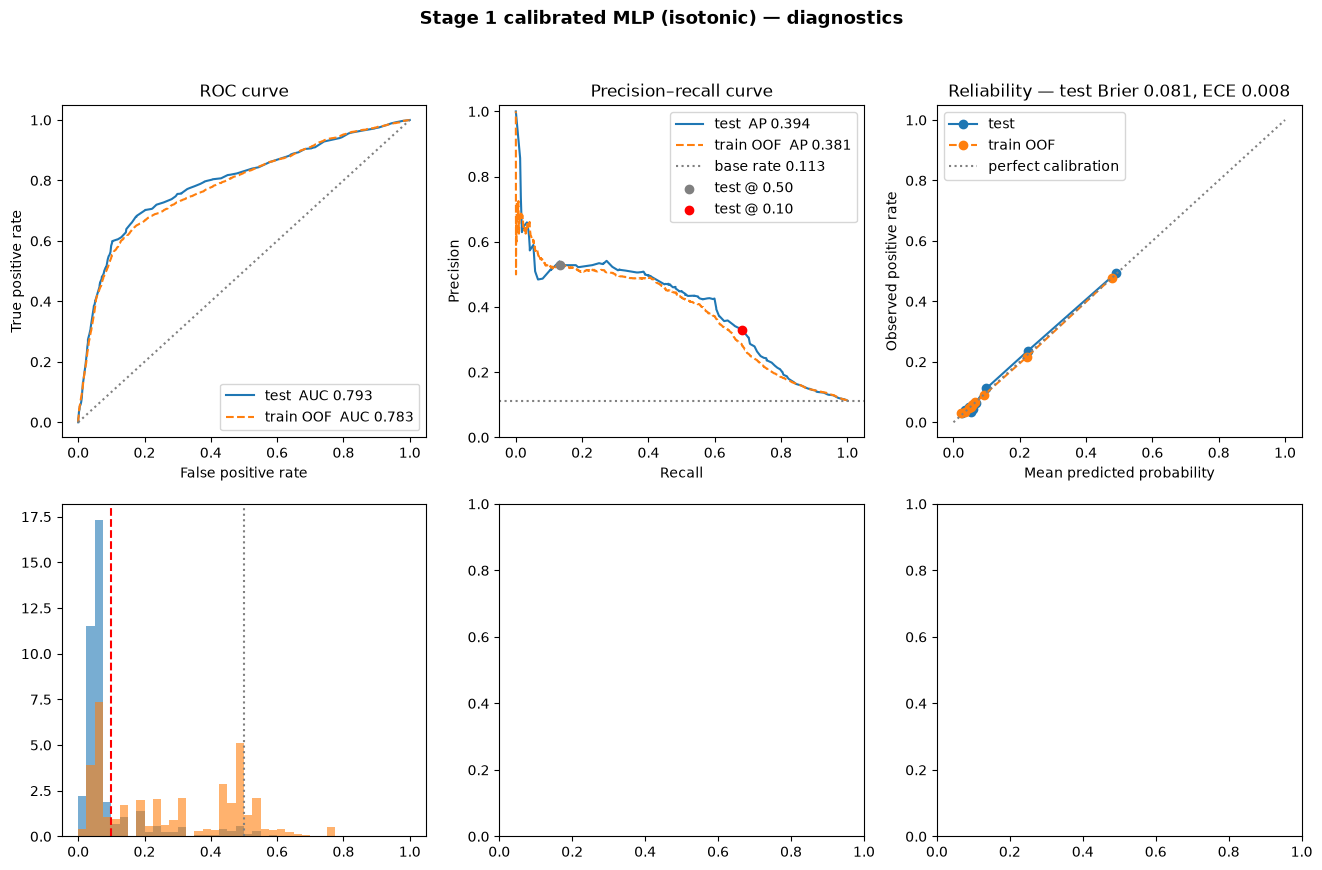

In [14]:
# ============================================================
# CELL 13: PLOT STAGE 1 THRESHOLD AND PROBABILITY DIAGNOSTICS
# ============================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, roc_curve

fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
fig.suptitle(f"Stage 1 calibrated MLP ({stage1.calibration_method}) — diagnostics",
             fontsize=13, fontweight="bold")

# ROC
ax = axes[0, 0]
for label, yy, pp, ls, m in (("test", y_te, p_te, "-", m_te_05), ("train OOF", y_tr, p_oof, "--", m_tr_05)):
    fpr, tpr, _ = roc_curve(yy, pp)
    ax.plot(fpr, tpr, ls, label=f"{label}  AUC {m['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], ":", color="grey")
ax.set(title="ROC curve", xlabel="False positive rate", ylabel="True positive rate")
ax.legend(loc="lower right")

# Precision-recall
ax = axes[0, 1]
for label, yy, pp, ls, m in (("test", y_te, p_te, "-", m_te_05), ("train OOF", y_tr, p_oof, "--", m_tr_05)):
    prec, rec, _ = precision_recall_curve(yy, pp)
    ax.plot(rec, prec, ls, label=f"{label}  AP {m['pr_auc']:.3f}")
ax.axhline(y_te.mean(), ls=":", color="grey", label=f"base rate {y_te.mean():.3f}")
ax.scatter(m_te_05["recall"], m_te_05["precision"], color="grey", zorder=5, label="test @ 0.50")
ax.scatter(m_te_thr["recall"], m_te_thr["precision"], color="red", zorder=5, label=f"test @ {thr:.2f}")
ax.set(title="Precision–recall curve", xlabel="Recall", ylabel="Precision", ylim=(0, 1.02))
ax.legend(loc="upper right")

# Reliability (calibrated)
ax = axes[0, 2]
for label, yy, pp, ls in (("test", y_te, p_te, "-"), ("train OOF", y_tr, p_oof, "--")):
    frac_pos, mean_pred = calibration_curve(yy, pp, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o" + ls, label=label)
ax.plot([0, 1], [0, 1], ":", color="grey", label="perfect calibration")
ax.set(title=f"Reliability — test Brier {m_te_05['brier']:.3f}, ECE {m_te_05['ece']:.3f}",
       xlabel="Mean predicted probability", ylabel="Observed positive rate")
ax.legend(loc="upper left")

# Probability distribution by class
ax = axes[1, 0]
bins = np.linspace(0, 1, 41)
ax.hist(p_te[y_te == 0], bins=bins, alpha=0.6, density=True, label="y = 0")
ax.hist(p_te[y_te == 1], bins=bins, alpha=0.6, density=True, label="y = 1")
ax.axvline(0.5, color="grey", ls=":", label="0.50")
ax.axvline(thr, color="red", ls="--", label=f"CV threshold {thr:.2f}")

## Cell 14 — Tune and Evaluate the Stage 1 Threshold

Selects the F2-optimal decision threshold from the **training OOF probabilities**, then applies it to both OOF train and held-out test probabilities.

The cell:

* tunes the threshold using `y_train` and `proba_train_oof`;
* updates the Stage 1 threshold and predictions;
* compares metrics at 0.50 and the tuned threshold;
* plots training OOF F2 across the threshold sweep.

Test labels are used only for evaluation, not threshold selection.

threshold: 0.100  [in_stage_f2_cv]  (CV F2 0.5397)

                  accuracy  precision  recall      f1      f2  roc_auc  pr_auc   brier     ece  pred_pos_rate
train OOF @ 0.50    0.8890     0.5247  0.1519  0.2356  0.1771   0.7829  0.3814  0.0819  0.0028         0.0326
train OOF @ 0.10    0.8049     0.3201  0.6514  0.4293  0.5397   0.7829  0.3814  0.0819  0.0028         0.2292
test @ 0.50         0.8891     0.5297  0.1347  0.2148  0.1583   0.7930  0.3942  0.0806  0.0083         0.0286
test @ 0.10         0.8078     0.3293  0.6810  0.4440  0.5612   0.7930  0.3942  0.0806  0.0083         0.2329


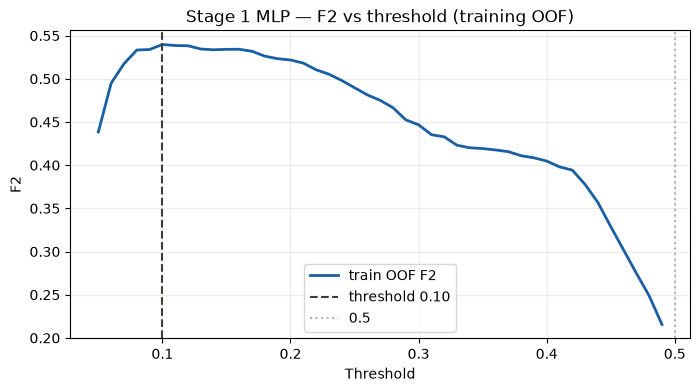

In [15]:
# ============================================================
# CELL 14: STAGE 1 DECISION THRESHOLD         
# ============================================================
# The in-stage F2 sweep chosen during fit (0.05–0.49 step 0.01, ties → lowest)
# — the same procedure GLASS uses (audit F7).
from blackbox_pipeline.models.mlp.evaluation import metrics_table
STAGE1_THRESHOLD = stage1.optimal_threshold
STAGE1_THRESHOLD_SOURCE = stage1.THRESHOLD_SOURCE

STAGE1_OUTPUT["threshold"] = STAGE1_THRESHOLD
STAGE1_OUTPUT["threshold_source"] = STAGE1_THRESHOLD_SOURCE
STAGE1_OUTPUT["pred_train_oof"] = (STAGE1_OUTPUT["proba_train_oof"] >= STAGE1_THRESHOLD).astype("int8")
STAGE1_OUTPUT["pred_test"] = (STAGE1_OUTPUT["proba_test"] >= STAGE1_THRESHOLD).astype("int8")

stage1_metrics = pd.concat([
    metrics_table(STAGE1["y_train"], STAGE1_OUTPUT["proba_train_oof"], "train OOF",
                  thresholds=(0.5, STAGE1_THRESHOLD), calibration_method=stage1.calibration_method),
    metrics_table(STAGE1["y_test"], STAGE1_OUTPUT["proba_test"], "test",
                  thresholds=(0.5, STAGE1_THRESHOLD), calibration_method=stage1.calibration_method),
])

print(f"threshold: {STAGE1_THRESHOLD:.3f}  [{STAGE1_THRESHOLD_SOURCE}]  (CV F2 {stage1.cv_f2:.4f})\n")
print(stage1_metrics.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(stage1.threshold_sweep["threshold"], stage1.threshold_sweep["f_beta"],
        color="#185FA5", lw=2, label="train OOF F2")
ax.axvline(STAGE1_THRESHOLD, color="#3d3d3a", ls="--", lw=1.5, label=f"threshold {STAGE1_THRESHOLD:.2f}")
ax.axvline(0.5, color="#b4b2a9", ls=":", lw=1.5, label="0.5")
ax.set(title="Stage 1 MLP — F2 vs threshold (training OOF)", xlabel="Threshold", ylabel="F2")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

In [16]:
# ============================================================
# CELL 14A: VALIDATION SETUP — STAGE 1 HAND-OFF OBJECT
# ============================================================
from pathlib import Path
from IPython.display import display
from sklearn.metrics import roc_auc_score, fbeta_score
from sklearn.model_selection import StratifiedKFold

from shared.stage_io import (
    StageOutput, ThresholdContaminationError, assert_comparable, split_fingerprint,
)
from shared.validation import ValidationReport
from blackbox_pipeline.models.mlp import save_stage1_mlp, load_stage1_mlp
from glass_pipeline.lr.feature_engineering import LR_FEATURES

VALIDATION = ValidationReport()

MLP_S1 = stage1.to_stage_output(
    STAGE1["X_test"], STAGE1["y_test"],
    threshold=STAGE1_THRESHOLD, threshold_source=STAGE1_THRESHOLD_SOURCE,
    metrics_test=stage1_metrics.loc[f"test @ {STAGE1_THRESHOLD:.2f}"].to_dict(),
)
MLP_S1_PATH = MLP_S1.save("./models/mlp")
MLP_ARTIFACT_PATH = save_stage1_mlp(stage1, "./models/mlp", stage_output=MLP_S1,
                                    test_metrics=MLP_S1.metrics_test)

GLASS_S1_PATH = Path("./models/lr/stage1_glass_output.joblib")
GLASS_S1 = StageOutput.load(GLASS_S1_PATH)           # written by the GLASS notebook (Cell 8A)

_TRAIN_IDX = GLOBAL_SPLIT["X_train"].index
_TEST_IDX = GLOBAL_SPLIT["X_test"].index
_Y_TR = GLOBAL_SPLIT["y_train"]
_Y_TE = GLOBAL_SPLIT["y_test"]
_FP = split_fingerprint(_TRAIN_IDX, _TEST_IDX, _Y_TR, _Y_TE)
SPLIT_FP = _FP

STAGE1_OUTPUT["split_fingerprint"] = MLP_S1.split_fingerprint

print(f"split fingerprint : {_FP}   (GLASS: {GLASS_S1.split_fingerprint})")
print(f"Stage 1 contract  : {MLP_S1}")
print(f"saved             : {MLP_S1_PATH}")
print(f"artifact          : {MLP_ARTIFACT_PATH}")

✅ stage1/blackbox → models\mlp\stage1_blackbox_output.joblib
✅ saved Stage 1 MLP → models\mlp\stage1_mlp.joblib
split fingerprint : d6cddadc3439   (GLASS: d6cddadc3439)
Stage 1 contract  : StageOutput(stage1/blackbox/calibrated_mlp, n_train=32950, n_test=8238, t=0.100 [FITTED-ON-TRAIN], cal=isotonic)
saved             : models\mlp\stage1_blackbox_output.joblib
artifact          : models\mlp\stage1_mlp.joblib


## Cell 15 — Stage 2 experiment constants

Defines the RF parameter source and tuning budget used by later cells.

* `"artifact"` — load saved RF parameters from `RF_ARTIFACT_DIRS`.
* `"tune"` — run `RF_TUNE_TRIALS` fresh trials.
* `"explicit"` — use `RF_PARAMS_EXPLICIT` directly.

`RF_PASS2_PARAMS = None` reuses Pass 1 hyperparameters for Pass 2. Separate Pass 2 tuning is valid only on its own OOF remainder, not against reported results.

In [17]:
# ============================================================
# CELL 15: STAGE 2 EXPERIMENT CONSTANTS
# ============================================================
from pathlib import Path

RF_PARAM_SOURCE = "artifact"          # "artifact" | "tune" | "explicit"

RF_ARTIFACT_DIRS = [
    BANK_ROOT / "models" / "rf",
    GLASS_ROOT / "models" / "rf",
    BLACKBOX_ROOT / "models" / "rf",
    PROTOTYPE_ROOT / "models" / "rf",
]

# Where the GLASS notebook's Cell 16 writes glass_router_<timestamp>.joblib
GLASS_ARTIFACT_DIRS = [
    BANK_ROOT / "models" / "glass_router",
    GLASS_ROOT / "models" / "glass_router",
    PROTOTYPE_ROOT / "models" / "glass_router",
]

RF_TUNE_TRIALS = 100

RF_PARAMS_EXPLICIT = {
    "n_estimators": 500,
    "max_depth": None,
    "min_samples_leaf": 20,
    "max_features": "sqrt",
    "minority_weight": 1.0,
    "class_weight": "balanced",
}

RF_PASS2_PARAMS = None

# Shared fold plan: 5 stratified folds, same seed as the GLASS cross-fit and Stage 3.
N_STAGE_FOLDS = 5

assert RF_PARAM_SOURCE in ("artifact", "tune", "explicit"), RF_PARAM_SOURCE
print(f"RF_PARAM_SOURCE = {RF_PARAM_SOURCE!r}")

RF_PARAM_SOURCE = 'artifact'


## Cell 16 — Import Stage 2 feature engineering

Imports `glass_router` RF feature engineering and fixes the shared 29-bin representation.

The assertion ensures Cell 4's Stage 1 `engineer_features` was not accidentally replaced by the RF version. If it fails, re-run Cell 4.

`RF_FEATURES_BINARY` must contain exactly 29 binary features, matching the representation used by both arms.

In [18]:
# ============================================================
# CELL 16: IMPORT STAGE 2 FEATURE ENGINEERING 
# ============================================================
import sys

from glass_pipeline.glass_router.rf import feature_engineering as _glass_fe
from glass_pipeline.glass_router.rf import binning as _glass_binning

engineer_rf_features = _glass_fe.engineer_features
RF_SOURCE_FEATURES = list(_glass_fe.RF_SOURCE_FEATURES)
RF_FEATURES_BINARY = list(_glass_binning.RF_FEATURES_BINARY)

print(f"engineer_rf_features ← {_glass_fe.__file__}")
print(f"RF_FEATURES_BINARY   : {len(RF_FEATURES_BINARY)} bins")
assert len(RF_FEATURES_BINARY) == 29, "Expected the locked 29-bin feature list"

# Guard against the collision: Stage 1 must still be the LR engineer.
assert engineer_features is not engineer_rf_features, (
    "`engineer_features` (Stage 1 / LR) was overwritten by the RF version — "
    "re-run Cell 4."
)

engineer_rf_features ← c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline\glass_pipeline\glass_router\rf\feature_engineering.py
RF_FEATURES_BINARY   : 29 bins


## Cell 17 — Build Stage 2 binary features

Fits RF feature engineering on train, applies it to train and test, and stores the result in `GLASS_ROUTER_DATA`.

Assertions verify row alignment, exact feature names and order, binary values, and disjoint train/test indices.

Cell 19 repeats key split checks intentionally so failures can be localized to either feature engineering or routing.

In [19]:
# ============================================================
# CELL 17: BUILD STAGE 2 BINARY FEATURES (GLASS_ROUTER_DATA)
# ============================================================
X_eng_train, X_eng_test = quiet(
    engineer_rf_features,
    GLOBAL_SPLIT["X_train"],
    GLOBAL_SPLIT["X_test"],
    GLOBAL_SPLIT["y_train"],
)

GLASS_ROUTER_DATA = {
    "X_eng_train": X_eng_train,
    "X_eng_test": X_eng_test,
    "y_eng_train": GLOBAL_SPLIT["y_train"],
    "y_eng_test": GLOBAL_SPLIT["y_test"],
}

assert X_eng_train.index.equals(GLOBAL_SPLIT["X_train"].index)
assert X_eng_test.index.equals(GLOBAL_SPLIT["X_test"].index)
assert list(X_eng_train.columns) == RF_FEATURES_BINARY
assert X_eng_train.isin([0, 1]).all().all() and X_eng_test.isin([0, 1]).all().all()
assert len(X_eng_train.index.intersection(X_eng_test.index)) == 0

print(f"GLASS_ROUTER_DATA: train {X_eng_train.shape} | test {X_eng_test.shape}")
print(f"train base rate: {GLASS_ROUTER_DATA['y_eng_train'].mean():.4f}")

GLASS_ROUTER_DATA: train (32950, 29) | test (8238, 29)
train base rate: 0.1127


## Cell 18 — Import the router and verify the shared split

Imports the Stage 2 router and computes `SPLIT_FP`, a fingerprint of the train/test row indices.

The fingerprint is stored with fitted routers and checked on reload, preventing evaluation against a different split that may contain training rows.

`unpack_global_split` also confirms the engineered frames preserve the original row identities and order.

In [20]:
# ============================================================
# CELL 18: IMPORT THE RF ROUTER AND VERIFY THE SHARED SPLIT
# ============================================================
from blackbox_pipeline.models.rf_router.evaluation.router_metrics import (
    compare_routers,
    evaluate_router,
)
from blackbox_pipeline.models.rf_router import (
    OperatingConstraints,
    RFRouter,
    RFRouterConfig,
    SingleRFRouter,
    load_rf_router,
    save_rf_router,
    split_fingerprint,
    unpack_global_split,
)
from glass_pipeline.glass_router.pipeline import make_folds, fold_fingerprint

STAGE2 = unpack_global_split(GLOBAL_SPLIT, engineered=GLASS_ROUTER_DATA)
SPLIT_FP = STAGE2["split_fingerprint"]

# One fold plan for everything that produces train-side OOF outputs.
# Same StratifiedKFold(5, shuffle=True, random_state) as crossfit_stage2 and
# rf_router.oof.make_folds, so identical y order -> identical folds.
STAGE_FOLDS = make_folds(STAGE2["y_train"], N_STAGE_FOLDS, RANDOM_STATE)
STAGE_FOLD_ID = np.full(len(STAGE2["y_train"]), -1)

for _k, (_tr, _va) in enumerate(STAGE_FOLDS):
    STAGE_FOLD_ID[_va] = _k

STAGE_FOLD_FP = fold_fingerprint(STAGE_FOLD_ID)

print(f"split fingerprint : {SPLIT_FP}")
print(f"fold fingerprint  : {STAGE_FOLD_FP}  ({N_STAGE_FOLDS} folds)")
print(f"train / test      : {STAGE2['n_train']:,} / {STAGE2['n_test']:,}")
print(f"rf_router         ← {sys.modules[RFRouter.__module__].__file__}")

split fingerprint : fc3e73a5ef91aea4
fold fingerprint  : 8aea082fcaf371b7  (5 folds)
train / test      : 32,950 / 8,238
rf_router         ← c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline\blackbox_pipeline\models\rf_router\router\two_pass.py


## Cell 18B — Load GLASS Router Stage 2 Artifact

Loads the newest GLASS Router artifact produced from the **same global split**.

The loader:

- searches configured artifact directories by modification time;
- skips unreadable or split-mismatched artifacts;
- verifies test-row ordering against `STAGE2["X_test"]`;
- requires train-side router outputs to be out-of-fold;
- reports whether the router fold fingerprint matches `STAGE_FOLD_FP`.

Execution stops if no compatible GLASS Router artifact is available.

In [21]:
# ============================================================
# CELL 18B: LOAD THE GLASS ROUTER STAGE 2 ARTIFACT (same split only)
# ============================================================
import joblib


def _latest_matching(dirs, pattern, expected_fp):
    """Newest artifact (by file time, across all dirs) whose split fingerprint matches."""
    files = [f for d in dirs if Path(d).is_dir() for f in Path(d).glob(pattern)]

    for f in sorted(files, key=lambda p: p.stat().st_mtime, reverse=True):
        try:
            obj = joblib.load(f)
        except Exception as exc:
            print(f"  (skip {f.name}: {type(exc).__name__})")
            continue

        fp = obj.get("split_fingerprint") if isinstance(obj, dict) else None

        if fp == expected_fp:
            return obj, f

        print(f"  (skip {f.name}: split_fingerprint {fp} != {expected_fp})")

    return None, None


GLASS_BUNDLE, GLASS_BUNDLE_PATH = _latest_matching(
    GLASS_ARTIFACT_DIRS,
    "glass_router_*.joblib",
    SPLIT_FP,
)

if GLASS_BUNDLE is None:
    raise FileNotFoundError(
        "No GLASS Router artifact for this split. Run the GLASS notebook through "
        "Cell 16, then re-run this cell."
    )

if not pd.Index(GLASS_BUNDLE["index_test"]).equals(STAGE2["X_test"].index):
    raise AssertionError("GLASS test outputs are not in this notebook's X_test order")

if GLASS_BUNDLE["train_outputs_oof"] is not True:
    raise AssertionError("GLASS train-side outputs are not OOF")

_glass_fold_fp = (GLASS_BUNDLE.get("oof_protocol") or {}).get("fold_fingerprint")

print(f"GLASS artifact    ← {GLASS_BUNDLE_PATH}")
print(f"GLASS fold fp     : {_glass_fold_fp} "
      f"({'MATCH' if _glass_fold_fp == STAGE_FOLD_FP else 'MISMATCH — folds differ'})")

GLASS artifact    ← c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline\models\glass_router\glass_router_20260924_133554.joblib
GLASS fold fp     : 8aea082fcaf371b7 (MATCH)


## Cell 19 — Declare the Stage 2 operating constraints

Defines the set-level constraints used to select both router thresholds.

Pass 1 routes `NOT_SUBSCRIBE` with NPV ≥ 0.95 and subscriber leakage ≤ 0.25. Pass 2 routes `SUBSCRIBE` with precision ≥ 0.42 and selects the largest feasible band, maximizing recall subject to that floor.

`recall_denominator="global"` measures Pass 2 recall against all training positives, matching GLASS's reporting convention.

Support floors are set to 125/75, slightly stricter than the GLASS-derived 100/50 defaults.

> GLASS applies constraints per rule, while the RF applies them to the routed set. Compare the measured set-level results from `evaluate_router`, not the configuration values directly.

In [22]:
# ============================================================
# CELL 19: DECLARE THE STAGE 2 OPERATING CONSTRAINTS (set-level)
# ============================================================

CONSTRAINT_SOURCE = "match_glass_oof"

GLASS_OOF_METRICS = evaluate_router(
    GLASS_BUNDLE["train_pred"],
    GLASS_BUNDLE["train_confidence"],
    GLASS_BUNDLE["train_decisions"],
    STAGE2["y_train"],
    label="GLASS Router (train OOF)",
)

if CONSTRAINT_SOURCE == "match_glass_oof":
    _m = GLASS_OOF_METRICS

    CONSTRAINTS = OperatingConstraints(
        min_precision_not_subscribe=float(_m["pass1_npv"]),
        max_subscriber_leakage_rate=float(_m["pass1_leakage_rate"]),
        max_subscriber_leakage_absolute=int(_m["pass1_subscribers_lost"]),
        min_pass1_coverage=None,
        min_precision_subscribe=float(_m["pass2_precision"]),
        min_recall_subscribe=None,
        recall_denominator="global",
        min_band_support_pass1=125,
        min_band_support_pass2=75,
    )
else:
    CONSTRAINTS = OperatingConstraints(
        min_precision_not_subscribe=0.95,
        max_subscriber_leakage_rate=0.25,
        max_subscriber_leakage_absolute=950,
        min_pass1_coverage=None,
        min_precision_subscribe=0.42,
        min_recall_subscribe=None,
        recall_denominator="global",
        min_band_support_pass1=125,
        min_band_support_pass2=75,
    )

print(f"CONSTRAINT_SOURCE = {CONSTRAINT_SOURCE!r}")
print(CONSTRAINTS)

CONSTRAINT_SOURCE = 'match_glass_oof'
OperatingConstraints(npv>=0.956, leak<=0.137/508, prec1>=0.291, recall>=None)


## Cell 20 — RF Hyperparameter Normalization

Defines the Stage 2 Random Forest parameter contract.

`_normalise_rf_params()` accepts either:

- already-normalized RF parameters; or
- raw Optuna `best_params`.

Raw search parameters are converted into the format expected by the router, including `max_depth`, `max_features`, minority weighting, and balanced class weights.

In [23]:
# ============================================================
# CELL 20: RESOLVE RF HYPERPARAMETERS
# ============================================================
import json

REQUIRED_PARAM_KEYS = (
    "n_estimators",
    "max_depth",
    "min_samples_leaf",
    "max_features",
    "minority_weight",
    "class_weight",
)


def _normalise_rf_params(raw: dict) -> dict:
    """Accept either normalised params or raw Optuna best_params."""
    if all(k in raw for k in REQUIRED_PARAM_KEYS):
        return {k: raw[k] for k in REQUIRED_PARAM_KEYS}

    # Raw Optuna shape — mirrors glass_router.rf.rf_training._normalize_params
    mf_type = raw.get("max_features_type", "sqrt")

    return {
        "n_estimators": raw["n_estimators"],
        "max_depth": raw.get("max_depth") if raw.get("use_max_depth") else None,
        "min_samples_leaf": raw["min_samples_leaf"],
        "max_features": (
            raw.get("max_features_fraction")
            if mf_type == "fraction"
            else mf_type
        ),
        "minority_weight": raw.get("minority_weight", 1.0),
        "class_weight": "balanced",
    }

## Cell 21 — Load RF Parameters from Artifact

Loads RF hyperparameters from the newest compatible GLASS RF artifact.

Only artifacts with the current `SPLIT_FP` are accepted because RF tuning is performed on `X_train`; parameters selected under another split may have been influenced by rows that are test data here.

The loaded parameters are normalized before use. Execution stops if no compatible artifact or parameter dictionary is found.

In [24]:
# ============================================================
# CELL 21: RF ARTIFACT PARAMETER LOADER 
# ============================================================
def _load_rf_params_from_artifact(dirs, expected_fp) -> tuple[dict, str]:
    """
    Params from the newest GLASS RF artifact fitted under this split.

    RF params were tuned with CV on X_train. An artifact from another split
    was tuned on rows that may now be test rows, so a fingerprint mismatch is
    skipped, not used.
    """
    obj, path = _latest_matching(
        dirs,
        "rf_result_*.joblib",
        expected_fp,
    )

    if obj is None:
        raise FileNotFoundError(
            "No RF artifact with split_fingerprint == "
            f"{expected_fp} in:\n"
            + "\n".join(f"  {d}" for d in dirs)
            + "\n\nRun the GLASS notebook's Cell 16 "
              "(it saves the RF artifact with its fingerprint), "
              "or set RF_PARAM_SOURCE = 'tune'."
        )

    if not isinstance(obj.get("params"), dict):
        raise KeyError(f"{path.name} has no 'params' dict")

    return _normalise_rf_params(obj["params"]), str(path)

## Cell 22 — Train-Only RF Hyperparameter Tuning

Defines the fallback RF tuning procedure used when `RF_PARAM_SOURCE="tune"`.

Optuna searches the same RF space used by the GLASS router with:

- 5-fold stratified CV;
- ROC-AUC as the optimization objective;
- balanced class weights;
- tunable minority sample weighting;
- training data only.

The best Optuna parameters are normalized into the shared Stage 2 RF parameter format.

In [25]:
# ============================================================
# CELL 22: DEFINE TRAIN-ONLY RF HYPERPARAMETER TUNING
# ============================================================
def _tune_rf_train_only(
    X,
    y,
    n_trials,
    random_state=RANDOM_STATE,
) -> dict:
    """Same search space as glass_router.rf.rf_training._tune_rf. X_train only."""
    import optuna

    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import roc_auc_score
    from sklearn.model_selection import StratifiedKFold
    from sklearn.pipeline import Pipeline

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=random_state,
    )

    def objective(trial):
        mf_type = trial.suggest_categorical(
            "max_features_type",
            ["sqrt", "log2", "fraction"],
        )

        use_depth = trial.suggest_categorical(
            "use_max_depth",
            [True, False],
        )

        params = dict(
            n_estimators=trial.suggest_int(
                "n_estimators",
                200,
                1200,
                step=50,
            ),
            max_depth=(
                trial.suggest_int("max_depth", 2, 12)
                if use_depth
                else None
            ),
            min_samples_leaf=trial.suggest_int(
                "min_samples_leaf",
                5,
                50,
            ),
            max_features=(
                trial.suggest_float(
                    "max_features_fraction",
                    0.3,
                    1.0,
                )
                if mf_type == "fraction"
                else mf_type
            ),
        )

        mw = trial.suggest_float(
            "minority_weight",
            1.0,
            3.0,
        )

        scores = []

        for tr, va in cv.split(X, y):
            pipe = Pipeline([
                (
                    "clf",
                    RandomForestClassifier(
                        **params,
                        class_weight="balanced",
                        random_state=random_state,
                        n_jobs=1,
                    ),
                )
            ])

            pipe.fit(
                X.iloc[tr],
                y.iloc[tr],
                clf__sample_weight=y.iloc[tr].map(
                    {0: 1.0, 1: mw}
                ).values,
            )

            scores.append(
                roc_auc_score(
                    y.iloc[va],
                    pipe.predict_proba(X.iloc[va])[:, 1],
                )
            )

        return float(np.mean(scores))

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=random_state),
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        show_progress_bar=True,
    )

    print(f"  best CV ROC-AUC: {study.best_value:.6f}")

    return _normalise_rf_params(study.best_params)

## Cell 23 — Resolve Stage 2 RF Hyperparameters

Selects the RF parameters used by Stage 2.

`RF_PARAM_SOURCE` supports:

- `"artifact"` — reuse parameters from a same-split GLASS RF artifact;
- `"tune"` — perform a fresh train-only Optuna search;
- otherwise — use `RF_PARAMS_EXPLICIT`.

The cell validates the required parameter keys, records their origin, and reports whether Pass 2 inherits the Pass 1 forest parameters or uses a separate configuration.

In [26]:
# ============================================================
# CELL 23: RESOLVE STAGE 2 RF HYPERPARAMETERS
# ============================================================
if RF_PARAM_SOURCE == "artifact":
    RF_PARAMS, RF_PARAMS_ORIGIN = _load_rf_params_from_artifact(
        RF_ARTIFACT_DIRS,
        SPLIT_FP,
    )

elif RF_PARAM_SOURCE == "tune":
    print(
        f"Tuning on X_train only — "
        f"{RF_TUNE_TRIALS} trials, 5-fold CV"
    )

    RF_PARAMS = _tune_rf_train_only(
        STAGE2["X_train"],
        STAGE2["y_train"],
        RF_TUNE_TRIALS,
    )

    RF_PARAMS_ORIGIN = (
        f"fresh train-only tune ({RF_TUNE_TRIALS} trials)"
    )

else:
    RF_PARAMS = _normalise_rf_params(
        RF_PARAMS_EXPLICIT
    )

    RF_PARAMS_ORIGIN = "RF_PARAMS_EXPLICIT"

missing = [
    key
    for key in REQUIRED_PARAM_KEYS
    if key not in RF_PARAMS
]

assert not missing, \
    f"RF_PARAMS missing keys: {missing}"

print(f"\nRF params ← {RF_PARAMS_ORIGIN}")
print(pd.Series(RF_PARAMS).to_string())

print(
    "\nPass 2 forest:",
    "inherits Pass 1 params"
    if RF_PASS2_PARAMS is None
    else "separate params",
)


RF params ← c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline\models\rf\rf_result_20260924_133553.joblib
n_estimators             650
max_depth                  6
min_samples_leaf          12
max_features        0.399898
minority_weight     1.300108
class_weight        balanced

Pass 2 forest: inherits Pass 1 params


## Cell 24 — Single-RF Two-Threshold Ablation

Fits the Stage 2 **single-RF ablation**.

A single Random Forest is trained with the resolved RF parameters and shared routing constraints. The router uses two operating thresholds to represent the NOT_SUBSCRIBE and SUBSCRIBE routing decisions while preserving an abstention region between them.

This provides the simpler baseline against which the two-pass RF router can be compared.

In [27]:
# ============================================================
# CELL 24: EXPERIMENT 1 — SINGLE-RF TWO-THRESHOLD ABLATION
# ============================================================
from dataclasses import replace

# At the legacy GLASS operating point (≈54% leakage, ≈27% Pass 2 precision) the
# two bands on one RF score overlap (t1 > t2): there is no abstain region, the
# same as GLASS legacy (≈0.1% abstain). Recorded as a finding; ordering check
# relaxed for the ablation only. Pass 1 still claims first, so decisions stay
# well defined.
ABLATION_CONSTRAINTS = replace(CONSTRAINTS, require_band_ordering=False)

ablation_config = RFRouterConfig(
    mode="single_rf",
    constraints=ABLATION_CONSTRAINTS,
    rf_params=RF_PARAMS,
    n_oof_folds=N_STAGE_FOLDS,
    random_state=RANDOM_STATE,
    verbose=True,
)
ablation = SingleRFRouter(ablation_config).fit(
    STAGE2["X_train"], STAGE2["y_train"], SPLIT_FP,
)
if ablation.thresholds_.t1 > ablation.thresholds_.t2:
    print(f"\n⚠️  FINDING: bands overlap (t1={ablation.thresholds_.t1:.4f} > "
          f"t2={ablation.thresholds_.t2:.4f}) — no abstain region at this operating point.")


── single-RF ablation ──────────────────────────────────
  out-of-fold scoring
   single-RF OOF: 32,950 rows, 5 folds
      fold 1/5: fit 26,360 → scored 6,590
      fold 2/5: fit 26,360 → scored 6,590
      fold 3/5: fit 26,360 → scored 6,590
      fold 4/5: fit 26,360 → scored 6,590
      fold 5/5: fit 26,360 → scored 6,590
  solving thresholds (train OOF only)
   t1 = 0.297107 | routes 12,687 (38.5%) | NPV 0.9600 | leaks 508 subs (13.69%)
   t2 = 0.437938 | flags 8,587 (26.1% of its population) | precision 0.2910 | recall 0.6732 (global denominator)
  refitting on the full training split
  RF ROUTER — single_rf (ablation)
  train rows          : 32,950
  training base rate  : 0.1127
  split fingerprint   : fc3e73a5ef91aea4
  t1 (route < t1)     : 0.297107
  t2 (flag  > t2)     : 0.437938
  pass1 band conf     : 0.9600 (n=12,687)
  pass2 band conf     : 0.2910 (n=8,587)


## Cell 25 — Two-Pass RF Router

Fits the full Stage 2 **two-pass RF router** on the training split.

The router uses:

- shared Stage 2 constraints and RF parameters;
- inner folds for threshold selection;
- a minimum Pass 2 remainder size;
- optional nested validation.

If enabled, the nested check is printed after fitting.

In [28]:
# ============================================================
# CELL 25: EXPERIMENT 2 — TWO-PASS RF ROUTER (full train -> test)
# ============================================================
VALIDATE_NESTED = True


def make_router_config(
    validate_nested=False,
    verbose=True,
):
    return RFRouterConfig(
        mode="two_pass",
        constraints=CONSTRAINTS,
        rf_params=RF_PARAMS,
        pass2_rf_params=RF_PASS2_PARAMS,
        n_oof_folds=N_STAGE_FOLDS,
        n_inner_folds=5,
        random_state=RANDOM_STATE,
        remainder_min_size=500,
        validate_nested=validate_nested,
        verbose=verbose,
    )


router = RFRouter(
    make_router_config(VALIDATE_NESTED)
).fit(
    STAGE2["X_train"],
    STAGE2["y_train"],
    SPLIT_FP,
)

if router.fit_report_.nested_check:
    print("\nNested cascade check:")
    print(
        pd.Series(
            router.fit_report_.nested_check
        ).to_string()
    )


── two-pass RF router ──────────────────────────────────
  [1/6] Pass 1 out-of-fold scoring
   pass1 OOF: 32,950 rows, 5 folds
      fold 1/5: fit 26,360 → scored 6,590
      fold 2/5: fit 26,360 → scored 6,590
      fold 3/5: fit 26,360 → scored 6,590
      fold 4/5: fit 26,360 → scored 6,590
      fold 5/5: fit 26,360 → scored 6,590
  [2/6] solving t1 (train OOF only)
   t1 = 0.297107 | routes 12,687 (38.5%) | NPV 0.9600 | leaks 508 subs (13.69%)
  [3/6] remainder: 20,263 rows (61.5%) survive Pass 1
  [4/6] Pass 2 out-of-fold scoring within the remainder
   pass2 OOF: 20,263 rows, 5 folds
      fold 1/5: fit 16,210 → scored 4,053
      fold 2/5: fit 16,210 → scored 4,053
      fold 3/5: fit 16,210 → scored 4,053
      fold 4/5: fit 16,211 → scored 4,052
      fold 5/5: fit 16,211 → scored 4,052
  [5/6] solving t2 (remainder OOF only)
   t2 = 0.342938 | flags 8,486 (41.9% of its population) | precision 0.2926 | recall 0.6689 (global denominator)
  [6/6] refitting both forests

  nest

## Cell 25B — Outer Cross-Fit for Stage 4

Generates leakage-safe Stage 2 train outputs for Stage 4.

For each shared outer fold:

1. feature engineering is fit on the other folds;
2. a complete two-pass RF router is fit on that training portion;
3. only the held-out fold is routed.

This produces OOF predictions, probabilities, confidence, decisions, and fold-level diagnostics where each row is processed by features, models, and thresholds that never saw its label.

The full-train router from Cell 25 remains responsible for test predictions.

In [29]:
# ============================================================
# CELL 25B: TWO-PASS RF ROUTER — OUTER CROSS-FIT (Stage 4 inputs)
# ============================================================
# Mirrors crossfit_stage2 on the GLASS side. For each shared fold:
#   engineer_features fit on the other folds (target-encoded features) -> bins
#   -> full RFRouter fit on those bins (its own inner OOF + thresholds)
#   -> route ONLY the held-out fold.
#
# Every train row is routed by features, forests AND thresholds that never
# saw its label. router.predict_train_oof() is kept below as a diagnostic.

import time

X_raw_train = GLOBAL_SPLIT["X_train"]
y_train_s2 = STAGE2["y_train"]

assert X_raw_train.index.equals(y_train_s2.index)

n_tr = len(y_train_s2)

RF_OOF = {
    "pred": np.full(n_tr, -1, dtype=int),
    "confidence": np.zeros(n_tr),
    "decisions": np.array(
        ["uncertain"] * n_tr,
        dtype=object,
    ),
    "proba": np.zeros((n_tr, 2)),
}

_fold_rows = []
_t0 = time.time()

for k, (tr, va) in enumerate(STAGE_FOLDS):
    Xtr_eng, Xva_eng = quiet(
        engineer_rf_features,
        X_raw_train.iloc[tr],
        X_raw_train.iloc[va],
        y_train_s2.iloc[tr],
    )

    r_k = RFRouter(
        make_router_config(
            validate_nested=False,
            verbose=False,
        )
    ).fit(
        Xtr_eng,
        y_train_s2.iloc[tr],
        SPLIT_FP,
    )

    p, c, d = r_k.predict(Xva_eng)

    RF_OOF["pred"][va] = p
    RF_OOF["confidence"][va] = c
    RF_OOF["decisions"][va] = d
    RF_OOF["proba"][va] = r_k.predict_proba(Xva_eng)

    yv = y_train_s2.iloc[va].to_numpy()

    _fold_rows.append({
        "fold": k,
        "t1": r_k.thresholds_.t1,
        "t2": r_k.thresholds_.t2,
        "remainder_frac": r_k.fit_report_.remainder["fraction"],
        "pass1": (p == 0).mean(),
        "pass2": (p == 1).mean(),
        "abstain": (p == -1).mean(),
        "leak": (
            ((p == 0) & (yv == 1)).sum()
            / max((yv == 1).sum(), 1)
        ),
        "seconds": round(
            time.time() - _t0,
            1,
        ),
    })

    print(
        f"   fold {k}: "
        f"t1 {r_k.thresholds_.t1:.4f} "
        f"t2 {r_k.thresholds_.t2:.4f} | "
        f"pass1 {(p == 0).mean():.1%} "
        f"pass2 {(p == 1).mean():.1%} "
        f"abstain {(p == -1).mean():.1%}"
    )

    del r_k

RF_OOF_FOLDS = pd.DataFrame(_fold_rows)

RF_OOF_PROTOCOL = {
    "train_outputs_oof": True,
    "n_folds": N_STAGE_FOLDS,
    "fold_fingerprint": STAGE_FOLD_FP,
    "random_state": RANDOM_STATE,
    "feature_engineering":
        "engineer_features refit per fold; locked bins",
    "router":
        "full RFRouter refit per fold (inner OOF + per-fold t1/t2)",
    "pass2_population":
        "OOF Pass 1 remainder (RF router design)",
    "test_outputs":
        "from the full-train router (Cell 25)",
}

print(
    f"\n⏱️  outer cross-fit: "
    f"{time.time() - _t0:.0f}s"
)

# Diagnostic: how different is the cheaper predict_train_oof path?
_p_cheap, _, _d_cheap = router.predict_train_oof()

print(
    "decision agreement, outer cross-fit vs predict_train_oof: "
    f"{(_d_cheap == RF_OOF['decisions']).mean():.4f}"
)

   fold 0: t1 0.3020 t2 0.3256 | pass1 39.2% pass2 25.9% abstain 34.9%
   fold 1: t1 0.3043 t2 0.3225 | pass1 37.7% pass2 26.9% abstain 35.4%
   fold 2: t1 0.3031 t2 0.3229 | pass1 42.6% pass2 25.5% abstain 31.9%
   fold 3: t1 0.2945 t2 0.3566 | pass1 38.7% pass2 26.2% abstain 35.1%
   fold 4: t1 0.2882 t2 0.3455 | pass1 40.1% pass2 25.2% abstain 34.7%

⏱️  outer cross-fit: 107s
decision agreement, outer cross-fit vs predict_train_oof: 0.9033


## Cell 26 — Inspect the Frozen Operating Point

Visualizes the train-OOF threshold sweeps used to select the final Stage 2 operating point.

The plots show:

- Pass 1 coverage, NPV, and subscriber leakage;
- Pass 2 flagged coverage, precision, and recall;
- configured constraint boundaries;
- the selected `t1` and `t2`.

The final feasible rows are also printed to show which constraints bind near the chosen thresholds.

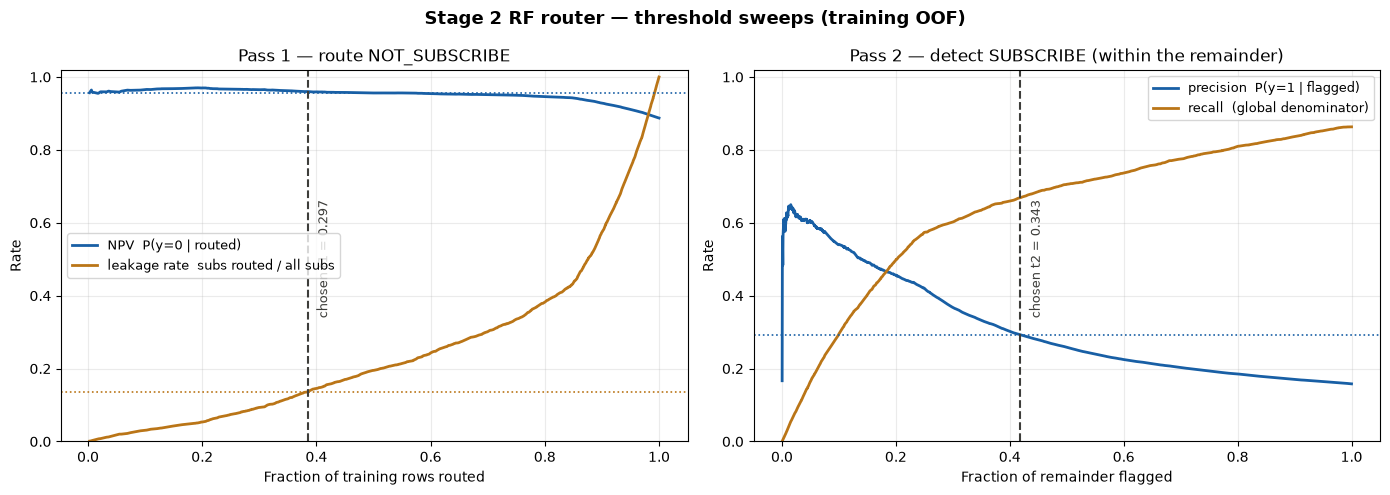

Which constraint binds at the chosen band:
 band_size  coverage    npv  subscribers_routed  leakage_rate  threshold  feasible binding
     12664    0.3843 0.9600                 506        0.1363     0.2964      True        
     12670    0.3845 0.9601                 506        0.1363     0.2966      True        
     12687    0.3850 0.9600                 508        0.1369     0.2971      True        

 band_size  band_fraction  precision  positives_in_band  recall  threshold  feasible binding
      8392         0.4142     0.2950               2476  0.6670     0.3432      True        
      8393         0.4142     0.2950               2476  0.6670     0.3431      True        
      8486         0.4188     0.2926               2483  0.6689     0.3429      True        


In [30]:
# ============================================================
# CELL 26: INSPECT THE FROZEN OPERATING POINT (TRAINING OOF ONLY)
# ============================================================
import matplotlib.pyplot as plt

p1_sweep = router.thresholds_.pass1.sweep
p2_sweep = router.thresholds_.pass2.sweep

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

fig.suptitle(
    "Stage 2 RF router — threshold sweeps (training OOF)",
    fontsize=13,
    fontweight="bold",
)

# Pass 1
ax = axes[0]

ax.plot(
    p1_sweep["coverage"],
    p1_sweep["npv"],
    color="#185FA5",
    lw=2,
    label="NPV  P(y=0 | routed)",
)

ax.plot(
    p1_sweep["coverage"],
    p1_sweep["leakage_rate"],
    color="#BA7517",
    lw=2,
    label="leakage rate  subs routed / all subs",
)

ax.axhline(
    CONSTRAINTS.min_precision_not_subscribe,
    color="#185FA5",
    ls=":",
    lw=1.2,
)

ax.axhline(
    CONSTRAINTS.max_subscriber_leakage_rate,
    color="#BA7517",
    ls=":",
    lw=1.2,
)

ax.axvline(
    router.thresholds_.pass1.band_fraction,
    color="#3d3d3a",
    ls="--",
    lw=1.5,
)

ax.annotate(
    f"chosen t1 = {router.thresholds_.t1:.3f}",
    xy=(
        router.thresholds_.pass1.band_fraction,
        0.5,
    ),
    xytext=(6, 0),
    textcoords="offset points",
    fontsize=9,
    color="#3d3d3a",
    rotation=90,
    va="center",
)

ax.set(
    title="Pass 1 — route NOT_SUBSCRIBE",
    xlabel="Fraction of training rows routed",
    ylabel="Rate",
    ylim=(0, 1.02),
)

ax.grid(alpha=0.25)
ax.legend(
    loc="center left",
    fontsize=9,
)

# Pass 2
ax = axes[1]

ax.plot(
    p2_sweep["band_fraction"],
    p2_sweep["precision"],
    color="#185FA5",
    lw=2,
    label="precision  P(y=1 | flagged)",
)

ax.plot(
    p2_sweep["band_fraction"],
    p2_sweep["recall"],
    color="#BA7517",
    lw=2,
    label=(
        f"recall  "
        f"({CONSTRAINTS.recall_denominator} denominator)"
    ),
)

ax.axhline(
    CONSTRAINTS.min_precision_subscribe,
    color="#185FA5",
    ls=":",
    lw=1.2,
)

if CONSTRAINTS.min_recall_subscribe is not None:
    ax.axhline(
        CONSTRAINTS.min_recall_subscribe,
        color="#BA7517",
        ls=":",
        lw=1.2,
    )

ax.axvline(
    router.thresholds_.pass2.band_fraction,
    color="#3d3d3a",
    ls="--",
    lw=1.5,
)

ax.annotate(
    f"chosen t2 = {router.thresholds_.t2:.3f}",
    xy=(
        router.thresholds_.pass2.band_fraction,
        0.5,
    ),
    xytext=(6, 0),
    textcoords="offset points",
    fontsize=9,
    color="#3d3d3a",
    rotation=90,
    va="center",
)

ax.set(
    title="Pass 2 — detect SUBSCRIBE (within the remainder)",
    xlabel="Fraction of remainder flagged",
    ylabel="Rate",
    ylim=(0, 1.02),
)

ax.grid(alpha=0.25)
ax.legend(
    loc="upper right",
    fontsize=9,
)

plt.tight_layout()
plt.show()

print("Which constraint binds at the chosen band:")

print(
    p1_sweep[
        p1_sweep["feasible"]
    ].tail(3).round(4).to_string(index=False)
)

print()

print(
    p2_sweep[
        p2_sweep["feasible"]
    ].tail(3).round(4).to_string(index=False)
)

## Cell 27 — Training-OOF Sanity Check

Summarizes the frozen operating points for the single-RF and two-pass routers using training OOF results only.

The comparison includes thresholds, routing coverage, Pass 1 leakage/NPV, Pass 2 precision/recall, and remainder size.

The cell also verifies both routers are fitted and were trained under the current split fingerprint.

In [31]:
# ============================================================
# CELL 27: TRAINING-OOF SANITY CHECK (STILL NO TEST DATA)
# ============================================================
_train_oof_summary = pd.DataFrame({
    "single_rf": {
        "t1":
            ablation.thresholds_.t1,

        "t2":
            ablation.thresholds_.t2,

        "pass1 band frac":
            ablation.thresholds_.pass1.band_fraction,

        "pass1 NPV (OOF)":
            ablation.bands_.pass1_confidence,

        "pass1 leakage (OOF)":
            ablation.thresholds_.pass1.leakage_rate,

        "pass2 band frac":
            ablation.thresholds_.pass2.band_fraction,

        "pass2 precision (OOF)":
            ablation.bands_.pass2_confidence,

        "pass2 recall (OOF)":
            ablation.thresholds_.pass2.recall,

        "remainder frac":
            float("nan"),
    },

    "two_pass": {
        "t1":
            router.thresholds_.t1,

        "t2":
            router.thresholds_.t2,

        "pass1 band frac":
            router.thresholds_.pass1.band_fraction,

        "pass1 NPV (OOF)":
            router.bands_.pass1_confidence,

        "pass1 leakage (OOF)":
            router.thresholds_.pass1.leakage_rate,

        "pass2 band frac":
            router.thresholds_.pass2.band_fraction,

        "pass2 precision (OOF)":
            router.bands_.pass2_confidence,

        "pass2 recall (OOF)":
            router.thresholds_.pass2.recall,

        "remainder frac":
            router.fit_report_.remainder["fraction"],
    },
})

print(
    _train_oof_summary
    .round(4)
    .to_string()
)

assert ablation.is_fitted
assert router.is_fitted

assert (
    ablation.split_fingerprint_
    == router.split_fingerprint_
    == SPLIT_FP
)

print(
    "\n✅ both operating points frozen; "
    "fingerprints match the shared split"
)

                       single_rf  two_pass
t1                        0.2971    0.2971
t2                        0.4379    0.3429
pass1 band frac           0.3850    0.3850
pass1 NPV (OOF)           0.9600    0.9600
pass1 leakage (OOF)       0.1369    0.1369
pass2 band frac           0.2606    0.4188
pass2 precision (OOF)     0.2910    0.2926
pass2 recall (OOF)        0.6732    0.6689
remainder frac               NaN    0.6150

✅ both operating points frozen; fingerprints match the shared split


## Cell 28 — Pass 1 vs Pass 2 Agreement

Measures how differently the two RF passes rank rows within the Pass 1 remainder.

The cell compares:

- Spearman correlation between Pass 1 and Pass 2 probabilities;
- the rows flagged by Pass 2;
- an equally sized high-score set based on Pass 1;
- agreement between those two selections.

This shows whether Pass 2 contributes meaningfully different ranking behavior rather than simply reproducing Pass 1.

In [32]:
# ============================================================
# CELL 28: PASS 1 VS PASS 2 AGREEMENT ANALYSIS
# ============================================================
rem = router.remainder_mask_

p1 = router.oof_pass1_proba_[rem]
p2 = router.oof_pass2_proba_[rem]

_flag_rate = (
    p2 > router.thresholds_.t2
).mean()

print(
    "spearman(p1, p2) on remainder : "
    f"{pd.Series(p1).corr(pd.Series(p2), method='spearman'):.4f}"
)

print(
    "pass2 flagged by p2 > t2      : "
    f"{(p2 > router.thresholds_.t2).sum():,}"
)

print(
    "same rows by p1 rank          : "
    f"{(p1 > np.quantile(p1, 1 - _flag_rate)).sum():,}"
)

print(
    "agreement                     : "
    f"{(
        (p2 > router.thresholds_.t2)
        ==
        (p1 > np.quantile(p1, 1 - _flag_rate))
    ).mean():.4f}"
)

spearman(p1, p2) on remainder : 0.9701
pass2 flagged by p2 > t2      : 8,486
same rows by p1 rank          : 8,463
agreement                     : 0.9648


## Cell 29 — Stage 2 Comparison

Evaluates all Stage 2 router variants with the same metric code.

Two comparisons are reported:

- **Test:** GLASS Router, single-RF ablation, and two-pass RF router.
- **Train OOF:** GLASS Router vs two-pass RF using the exact outputs Stage 4 will consume.

Metrics cover routing coverage, abstention, Pass 1 leakage/NPV, Pass 2 precision/recall, and resolved predictive performance.

Per-fold outer cross-fit diagnostics are also reported for the two-pass RF router.

In [33]:
# ============================================================
# CELL 29: STAGE 2 COMPARISON — ALL ARMS, SAME METRIC CODE
# ============================================================
assert (
    split_fingerprint(
        STAGE2["X_train"],
        STAGE2["X_test"],
    )
    == SPLIT_FP
)

assert (
    len(
        STAGE2["X_train"].index.intersection(
            STAGE2["X_test"].index
        )
    )
    == 0
)

HEADLINE = [
    "coverage",
    "abstain_rate",
    "pass1_share",
    "pass1_npv",
    "pass1_subscribers_lost",
    "pass1_leakage_rate",
    "pass2_share",
    "pass2_precision",
    "pass2_recall",
    "abstain_base_rate",
    "resolved_accuracy",
    "resolved_f1",
]

# ------------------------------------------------------------
# TEST
# GLASS: saved full-train outputs
# RF arms: predicted here
# ------------------------------------------------------------
stage2_results = compare_routers(
    evaluate_router(
        GLASS_BUNDLE["test_pred"],
        GLASS_BUNDLE["test_confidence"],
        GLASS_BUNDLE["test_decisions"],
        STAGE2["y_test"],
        label="GLASS Router",
        base_rate=GLASS_BUNDLE["training_base_rate"],
    ),

    evaluate_router(
        *ablation.predict(STAGE2["X_test"]),
        STAGE2["y_test"],
        label="RF single (ablation)",
        base_rate=ablation.training_base_rate,
    ),

    evaluate_router(
        *router.predict(STAGE2["X_test"]),
        STAGE2["y_test"],
        label="RF two-pass",
        base_rate=router.training_base_rate,
    ),
)

print("Stage 2 — TEST split, set-level metrics")

print(
    stage2_results
    .loc[HEADLINE]
    .round(4)
    .to_string()
)

# ------------------------------------------------------------
# TRAIN OOF
# What Stage 4 will actually consume
# ------------------------------------------------------------
stage2_oof_results = compare_routers(
    GLASS_OOF_METRICS | {
        "label": "GLASS Router"
    },

    evaluate_router(
        RF_OOF["pred"],
        RF_OOF["confidence"],
        RF_OOF["decisions"],
        STAGE2["y_train"],
        label="RF two-pass",
    ),
)

print(
    "\nStage 2 — TRAIN OOF (outer cross-fit), "
    f"set-level metrics | constraints: {CONSTRAINT_SOURCE}"
)

print(
    stage2_oof_results
    .loc[HEADLINE]
    .round(4)
    .to_string()
)

print(
    "\nRF two-pass outer cross-fit, per fold:"
)

print(
    RF_OOF_FOLDS
    .round(4)
    .to_string(index=False)
)

Stage 2 — TEST split, set-level metrics
                        GLASS Router  RF single (ablation)  RF two-pass
coverage                      0.6117                0.6171       0.6374
abstain_rate                  0.3883                0.3829       0.3626
pass1_share                   0.3999                0.3638       0.3638
pass1_npv                     0.9532                0.9646       0.9646
pass1_subscribers_lost      154.0000              106.0000     106.0000
pass1_leakage_rate            0.1659                0.1142       0.1142
pass2_share                   0.2118                0.2533       0.2736
pass2_precision               0.3077                0.3067       0.2924
pass2_recall                  0.5787                0.6897       0.7101
abstain_base_rate             0.0741                0.0577       0.0546
resolved_accuracy             0.7297                0.6945       0.6761
resolved_f1                   0.4409                0.4518       0.4366

Stage 2 — TRAIN OOF (ou

## Cell 30 — Save Stage 2 Router Artifacts

Saves both RF router experiments with their evaluation metadata and provenance.

The two-pass artifact additionally stores the complete Stage 4 contract:

- OOF train predictions, probabilities, confidence, and decisions;
- shared fold IDs and OOF protocol metadata;
- full-train test outputs;
- split indices, constraint source, and RF parameter origin.

The saved two-pass artifact is reloaded immediately to verify its split and fold fingerprints and frozen thresholds.

In [34]:
# ============================================================
# CELL 30: SAVE THE ROUTERS (with OOF block + provenance)
# ============================================================
STAGE2_OUT = "./models/rf_router"

_idx_tr = STAGE2["X_train"].index
_idx_te = STAGE2["X_test"].index

# Save single-RF ablation
_ = save_rf_router(
    ablation,
    STAGE2_OUT,
    name="rf_router_single",
    test_metrics=stage2_results[
        "RF single (ablation)"
    ].to_dict(),
    extra_metadata={
        "index_train": _idx_tr,
        "index_test": _idx_te,
        "constraint_source": CONSTRAINT_SOURCE,
        "rf_params_origin": RF_PARAMS_ORIGIN,
    },
)

# Full two-pass test outputs
_p_te, _c_te, _d_te = router.predict(
    STAGE2["X_test"]
)

# Save two-pass router with Stage 4 OOF block
_ = save_rf_router(
    router,
    STAGE2_OUT,
    name="rf_router_two_pass",
    test_metrics=stage2_results[
        "RF two-pass"
    ].to_dict(),
    extra_metadata={
        "index_train": _idx_tr,
        "index_test": _idx_te,
        "constraint_source": CONSTRAINT_SOURCE,
        "rf_params_origin": RF_PARAMS_ORIGIN,
        "glass_artifact": str(GLASS_BUNDLE_PATH),

        # Stage 4 inputs — train side
        "train_outputs_oof": True,
        "train_pred": RF_OOF["pred"],
        "train_confidence": RF_OOF["confidence"],
        "train_decisions": RF_OOF["decisions"],
        "train_proba": RF_OOF["proba"],
        "train_fold_id": STAGE_FOLD_ID,
        "oof_protocol": RF_OOF_PROTOCOL,
        "oof_fold_summary":
            RF_OOF_FOLDS.to_dict("records"),

        # Test side — full-train router
        "test_pred": _p_te,
        "test_confidence": _c_te,
        "test_decisions": _d_te,
        "test_proba":
            router.predict_proba(STAGE2["X_test"]),
    },
)

_reloaded = load_rf_router(
    f"{STAGE2_OUT}/rf_router_two_pass.joblib",
    expected_split_fingerprint=SPLIT_FP,
)

assert (
    _reloaded["extra"]["oof_protocol"][
        "fold_fingerprint"
    ]
    == STAGE_FOLD_FP
)

print(
    f"\nreload OK — "
    f"t1={_reloaded['thresholds']['t1']:.6f} "
    f"t2={_reloaded['thresholds']['t2']:.6f} "
    f"| fold fp {STAGE_FOLD_FP}"
)

✅ saved single_rf router → models\rf_router\rf_router_single.joblib
   metadata     : models\rf_router\rf_router_single_metadata.json
   threshold sweeps written alongside
✅ saved two_pass router → models\rf_router\rf_router_two_pass.joblib
   metadata     : models\rf_router\rf_router_two_pass_metadata.json
   threshold sweeps written alongside

reload OK — t1=0.297107 t2=0.342938 | fold fp 8aea082fcaf371b7


In [35]:
# ============================================================
# CELL 31: PACKAGE STAGE 2 OUTPUTS FOR STAGE 3
# ============================================================
STAGE2_OUTPUT = {
    "router": router,
    "ablation": ablation,

    "t1": router.thresholds_.t1,
    "t2": router.thresholds_.t2,

    # Train side: outer cross-fit
    # Features, forests and thresholds are all OOF.
    "preds_train_oof": pd.Series(RF_OOF["pred"], index=_idx_tr),
    "conf_train_oof": pd.Series(RF_OOF["confidence"], index=_idx_tr),
    "decisions_train_oof": pd.Series(RF_OOF["decisions"], index=_idx_tr),
    "proba_train_oof": RF_OOF["proba"],
    "fold_id_train": pd.Series(STAGE_FOLD_ID, index=_idx_tr),

    # Test side: full-train router
    "preds_test": pd.Series(_p_te, index=_idx_te),
    "conf_test": pd.Series(_c_te, index=_idx_te),
    "decisions_test": pd.Series(_d_te, index=_idx_te),
    "proba_test": router.predict_proba(STAGE2["X_test"]),

    "metrics_test": stage2_results,
    "metrics_train_oof": stage2_oof_results,

    "split_fingerprint": SPLIT_FP,
    "fold_fingerprint": STAGE_FOLD_FP,
}

STAGE2_OUTPUT["abstain_train"] = STAGE2_OUTPUT["decisions_train_oof"] == "uncertain"
STAGE2_OUTPUT["abstain_test"] = STAGE2_OUTPUT["decisions_test"] == "uncertain"

# OOF vs in-sample: compare full decisions (pass1 / pass2 / uncertain), not only
# the abstain mask — at a near-zero-abstain operating point both masks are all
# False and match trivially.
_in_sample_d = router.predict(STAGE2["X_train"])[2]
_oof_d = STAGE2_OUTPUT["decisions_train_oof"].to_numpy()
_oof_ab = STAGE2_OUTPUT["abstain_train"].to_numpy()
_te_ab = STAGE2_OUTPUT["abstain_test"].to_numpy()

print(
    f"decision agreement, OOF vs in-sample: {(_oof_d == _in_sample_d).mean():.4f} "
    f"| abstains OOF {_oof_ab.sum():,} vs in-sample {(_in_sample_d == 'uncertain').sum():,}"
)
assert not np.array_equal(_oof_d, _in_sample_d), (
    "OOF and in-sample decisions identical — OOF path not being used"
)

print("\nStage 2 → Stage 3 handoff")
print(f"  train abstains (OOF): {_oof_ab.sum():,} ({_oof_ab.mean():.1%})")
print(f"  test  abstains      : {_te_ab.sum():,} ({_te_ab.mean():.1%})")
print(
    f"  train abstain base rate: "
    f"{STAGE2['y_train'][_oof_ab].mean():.4f}" if _oof_ab.any() else
    "  train abstain base rate: n/a (no abstains)"
)
print(
    f"  test  abstain base rate: "
    f"{STAGE2['y_test'][_te_ab].mean():.4f}" if _te_ab.any() else
    "  test  abstain base rate: n/a (no abstains)"
)
if not _oof_ab.any() or not _te_ab.any():
    print("\n⚠️  No (or almost no) abstains at this operating point (legacy-matched) — "
          "Stage 3 would receive an empty population; see PR 33.")

decision agreement, OOF vs in-sample: 0.8573 | abstains OOF 11,334 vs in-sample 12,071

Stage 2 → Stage 3 handoff
  train abstains (OOF): 11,334 (34.4%)
  test  abstains      : 2,987 (36.3%)
  train abstain base rate: 0.0616
  test  abstain base rate: 0.0546


## Cell 32 — Stage 3 experiment constants

`XGB_PARAM_SOURCE` selects the XGBoost hyperparameter source:

| Value        | Behaviour                                           |
| ------------ | --------------------------------------------------- |
| `"tune"`     | Run `XGB_TUNE_TRIALS` Optuna trials                 |
| `"explicit"` | Use `XGB_PARAMS_EXPLICIT` directly                  |
| `"artifact"` | Load `best_params` from the newest Stage 3 artifact |

Artifact parameters are valid only for the same split and feature contract.

`_newest()` selects the most recently modified artifact across `XGB_ARTIFACT_DIRS`, excluding `*_latest` copies.

In [36]:
# ============================================================
# CELL 32: STAGE 3 EXPERIMENT CONSTANTS
# ============================================================
from pathlib import Path

XGB_PARAM_SOURCE = "tune"            # "artifact" | "tune" | "explicit"

XGB_ARTIFACT_DIRS = [
    GLASS_ROOT / "models" / "xgb",
    BLACKBOX_ROOT / "models" / "xgb",
    PROTOTYPE_ROOT / "models" / "xgb",
]

XGB_TUNE_TRIALS = 150                # MIRROR — the EBM's Optuna budget

XGB_PARAMS_EXPLICIT = {              # read only when XGB_PARAM_SOURCE == "explicit"
    "n_estimators": 600,
    "learning_rate": 0.02,
    "max_depth": 4,
    "min_child_weight": 5.0,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_lambda": 1.0,
}


def _newest(dirs, pattern):
    """Newest file by modification time across ALL dirs; skips *_latest copies."""
    found = [p for d in map(Path, dirs) if d.exists()
             for p in d.glob(pattern) if not p.stem.endswith("_latest")]
    return max(found, key=lambda p: p.stat().st_mtime) if found else None


assert XGB_PARAM_SOURCE in ("artifact", "tune", "explicit"), XGB_PARAM_SOURCE
print(f"XGB_PARAM_SOURCE = {XGB_PARAM_SOURCE!r}")


XGB_PARAM_SOURCE = 'tune'


## Cell 33 — Stage 3 feature block

Both arms use the same GLASS feature pipeline:

`drop_leaky_features` → `engineer_ebm_features` → `select_ebm_features`

The black-box arm performs no independent feature engineering.

Assertions verify exact `EBM_FEATURES` order and alignment with `GLOBAL_SPLIT`. Only `y_train` is passed into feature engineering.

In [37]:
# ============================================================
# CELL 33: STAGE 3 FEATURE BLOCK — per-fold GLASS DAG (same as GLASS 19b)
# ============================================================
from glass_pipeline.ebm.feature_engineering import EBM_FEATURES, EBMFeaturePipeline
from blackbox_pipeline.models.xgb import XGBStage3Config
from shared.stage_runner import Stage3Block

XGB_STAGE3_CONFIG = XGBStage3Config(
    expected_features=list(EBM_FEATURES),
    n_trials=XGB_TUNE_TRIALS,
    artifact_dir=str(BLACKBOX_ROOT / "models" / "xgb"),
    verbose=True,
)
assert XGB_STAGE3_CONFIG.n_trials == 150, (
    f"XGB_TUNE_TRIALS={XGB_TUNE_TRIALS}: the EBM arm tunes with 150 trials; "
    "a different budget breaks the comparison."
)

_FP_NOW = split_fingerprint(GLOBAL_SPLIT["X_train"], GLOBAL_SPLIT["X_test"])
STAGE3_BLOCK = Stage3Block.from_global_split(
    GLOBAL_SPLIT, EBMFeaturePipeline, XGB_STAGE3_CONFIG, split_fingerprint=_FP_NOW,
)
assert STAGE3_BLOCK.features == list(EBM_FEATURES)
assert STAGE3_BLOCK.index_train.equals(GLOBAL_SPLIT["X_train"].index)
assert STAGE3_BLOCK.index_test.equals(GLOBAL_SPLIT["X_test"].index)
print(f"block fingerprint: {STAGE3_BLOCK.block_fingerprint}")

  Stage 3 block: fitting feature pipeline on all 32,950 training rows
  Stage 3 block: feature_fit_scope='per_fold' — refitting the feature pipeline inside each of 5 tuning + 10 reporting folds
  Stage 3 block: 13 features, train (32950, 13), test (8238, 13), fingerprint 4763072141627901…
block fingerprint: 47630721416279019a4ea545c9da570a790670f8449c92940b2929b7bcc77ea1


## Cell 34 — Stage 3 XGBoost

Trains the black-box counterpart to EBM while matching the split, features, seed, weighting, tuning objective, CV reporting, calibration rule, and threshold grid.

Training-side procedure:

1. Validate features and impute with train medians.
2. Build balanced weights and shared CV folds.
3. Tune with Optuna when required.
4. Produce the 10-fold CV report.
5. Refit on the full training set.
6. Generate OOF predictions for Stage 4.
7. Apply fold-nested isotonic calibration when OOF ECE > 0.05.
8. Select thresholds from OOF predictions.
9. Evaluate on test after all operating choices are frozen.

Recorded departures from GLASS include OOF-based thresholding and calibration, OOF Stage 4 outputs, train-derived imputation, and an XGBoost-specific search space.

`split_fingerprint` is stored for validation in Cell 38.

In [38]:
# ============================================================
# CELL 34: STAGE 3 — XGBOOST
# ============================================================
import joblib
from blackbox_pipeline.models.xgb import train_xgb_stage
from shared.stage3.protocol import check_param_reuse

_params = _params_source = _params_prov = None
if XGB_PARAM_SOURCE == "explicit":
    # NOTE: no Optuna search on record → Cell 36's protocol check will flag it.
    _params, _params_source = dict(XGB_PARAMS_EXPLICIT), "XGB_PARAMS_EXPLICIT"
elif XGB_PARAM_SOURCE == "artifact":
    _src = _newest(XGB_ARTIFACT_DIRS, "xgb_stage3_*.joblib")
    if _src is None:
        raise FileNotFoundError(
            f"XGB_PARAM_SOURCE='artifact' but no xgb_stage3_*.joblib in "
            f"{[str(d) for d in XGB_ARTIFACT_DIRS]}. Use 'tune' first."
        )
    _reuse = check_param_reuse(
        joblib.load(_src), XGB_STAGE3_CONFIG, _FP_NOW,
        STAGE3_BLOCK.block_fingerprint, list(EBM_FEATURES),
    )   # checks split, block, features, n_trials, search space, scope, seeds
    _params, _params_source, _params_prov = (
        _reuse["params"], f"{_src.name}: {_reuse['source']}", _reuse["provenance"])
    print(f"params ← {_params_source}")

XGB_STAGE3, XGB_STAGE3_PATH = train_xgb_stage(
    block=STAGE3_BLOCK,
    config=XGB_STAGE3_CONFIG,
    params=_params,
    params_source=_params_source,
    params_provenance=_params_prov,
)


  STAGE 3 — XGBOOST  (shared protocol; counterpart glass_pipeline.ebm)
  train 32,950 | test 8,238 | 13 features | fitted per_fold
  balanced sample weights: class 0 → 0.5635, class 1 → 4.4383 (positive class upweighted 7.9×)
  block fingerprint 4763072141627901…

  XGBOOST STAGE 3 TUNING — RECALL-BIASED (F2 at the 0.5 cut)
  rows         : 32,950  |  features fitted per_fold
  folds        : 5-fold, seed 42
  budget       : 150 trials, TPE(seed=42), MedianPruner(20/2)
  search space :
             n_estimators  int[200, 2000] step 100
            learning_rate  float[0.005, 0.05] log
                max_depth  int[2, 8]
         min_child_weight  float[1.0, 20.0] log
                subsample  float[0.6, 1.0]
         colsample_bytree  float[0.6, 1.0]
               reg_lambda  float[0.001, 10.0] log


  0%|          | 0/150 [00:00<?, ?it/s]


------------------------------------------------------------------------------
best CV F2 : 0.556589
trials     : 91 completed, 59 pruned, 0 failed of 150
runtime    : 1453.6s
features   : fitted per_fold
best params:
           n_estimators = 500
          learning_rate = 0.007593
              max_depth = 6
       min_child_weight = 4.325314
              subsample = 0.877711
       colsample_bytree = 0.752547
             reg_lambda = 0.025418
------------------------------------------------------------------------------

  10-fold cross-validation (final evaluation, seed 42)
     fold  1: AUC=0.7978  Recall=0.6388  Precision=0.3860  F1=0.4812  F2=0.5648
     fold  2: AUC=0.7798  Recall=0.6119  Precision=0.3815  F1=0.4700  F2=0.5459
     fold  3: AUC=0.8290  Recall=0.6658  Precision=0.3865  F1=0.4891  F2=0.5817
     fold  4: AUC=0.7827  Recall=0.5795  Precision=0.3923  F1=0.4679  F2=0.5290
     fold  5: AUC=0.7977  Recall=0.6199  Precision=0.3716  F1=0.4646  F2=0.5468
     fold  6:

## Cell 35 — Stage 4 hand-off

| Accessor              | Source                | Use              |
| --------------------- | --------------------- | ---------------- |
| `stage4_frame()`      | OOF train predictions | Train Stage 4    |
| `stage4_test_frame()` | Refit model on test   | Evaluate Stage 4 |

Both expose `proba`, `proba_calibrated`, `decision`, `confidence`, `margin`, `state`, and `fold_id`.

Train outputs are leakage-safe: probabilities are OOF, calibration is fold-nested, and decisions use per-fold thresholds chosen without that fold's labels.

Do not train Stage 4 on `refit["train_proba"]`; it is in-sample and diagnostic only.

Threshold spread measures stability. OOF F2 using a threshold selected on the same rows is mildly optimistic.

In [39]:
# ============================================================
# CELL 35: STAGE 4 HAND-OFF — OOF vs REFIT
# ============================================================
from sklearn.metrics import roc_auc_score

STAGE3_XGB_TRAIN = XGB_STAGE3.stage4_frame()             # OOF features — train Stage 4
STAGE3_XGB_TEST = XGB_STAGE3.stage4_test_frame()         # refit features — evaluate Stage 4
STAGE3_XGB_TEST_FOLDMEAN = XGB_STAGE3.stage4_test_frame(source="fold_mean")
STAGE3_XGB_TRAIN_META = XGB_STAGE3.stage4_metadata()     # NOT features

assert STAGE3_XGB_TRAIN.index.equals(GLOBAL_SPLIT["X_train"].index)
assert STAGE3_XGB_TEST.index.equals(GLOBAL_SPLIT["X_test"].index)
assert not any(c.endswith(("fold_id", "state", "threshold")) for c in STAGE3_XGB_TRAIN.columns)

print(STAGE3_XGB_TRAIN.head())
print(f"\ntrain side {STAGE3_XGB_TRAIN.shape} | test side {STAGE3_XGB_TEST.shape}")

_y = GLOBAL_SPLIT["y_train"]
_auc_oof = roc_auc_score(_y, XGB_STAGE3.oof["proba"])
_auc_ins = roc_auc_score(_y, XGB_STAGE3.refit["train_proba"])
print(f"\ntrain AUC  OOF {_auc_oof:.4f}  |  in-sample {_auc_ins:.4f}  "
      f"|  optimism {_auc_ins - _auc_oof:+.4f}   (features fitted "
      f"{XGB_STAGE3.feature_fit_scope})")

_nest = XGB_STAGE3.threshold["oof_nested"]
_m_sel = XGB_STAGE3.metrics["oof_at_operating_threshold"]
_m_nst = XGB_STAGE3.metrics["oof_at_nested_thresholds"]
print(f"\nthreshold  global {XGB_STAGE3.threshold['oof']['threshold']:.4f}  |  "
      f"per-fold {_nest['by_fold']}  (sd {_nest['std']:.4f})")
print(f"OOF F2     in-selection {_m_sel['f2']:.4f}  |  fold-nested {_m_nst['f2']:.4f}")

_cal = XGB_STAGE3.calibration
print(f"calibration {'applied' if _cal['applied'] else 'skipped'}  |  "
      f"OOF ECE {_cal['ece_before']:.4f} → {_cal['ece_after']:.4f}  |  "
      f"test ECE {_cal['test_ece_raw']:.4f} → {_cal['test_ece_calibrated']:.4f}  "
      f"({_cal['n_zero_after']} OOF rows at p=0)")
_rf = XGB_STAGE3.metrics["test_at_operating_threshold"]
_fm = XGB_STAGE3.metrics["test_fold_mean_at_operating_threshold"]
print(f"test F2    refit {_rf['f2']:.4f}  |  fold-mean {_fm['f2']:.4f}")

       xgb_stage3_proba  xgb_stage3_proba_calibrated  xgb_stage3_decision  \
25611          0.228817                     0.038724                    0   
26010          0.238238                     0.038166                    0   
40194          0.918130                     0.685714                    1   
297            0.178640                     0.029602                    0   
36344          0.792455                     0.324324                    1   

       xgb_stage3_confidence  xgb_stage3_margin  
25611               0.542365          -0.271183  
26010               0.503670          -0.241762  
40194               0.836259           0.418130  
297                 0.642720          -0.321360  
36344               0.600875           0.312455  

train side (32950, 5) | test side (8238, 5)

train AUC  OOF 0.7962  |  in-sample 0.8299  |  optimism +0.0337   (features fitted per_fold)

threshold  global 0.5000  |  per-fold [0.48, 0.5, 0.5, 0.5, 0.5]  (sd 0.0080)
OOF F2     in-selec

## Cell 36 — EBM vs XGBoost

Compares both models on the same test rows:

| View             | Purpose                                    |
| ---------------- | ------------------------------------------ |
| `ranking`        | Compare ROC-AUC, Brier, and ECE            |
| `matched_budget` | Compare recall at equal flagged coverage   |
| `as_operated`    | Compare each model at its stored threshold |

The EBM threshold was selected on `y_test`, while XGBoost uses OOF training predictions. `ranking` and `matched_budget` are therefore the cleaner like-for-like comparisons.

The split guard verifies shared test rows using `split_fingerprint`, `index_test`, prediction indices, or row count with a warning.

For the strongest check, store `split_fingerprint` and `index_test` in the GLASS Stage 3 artifact.

In [40]:
# ============================================================
# CELL 36: STAGE 3 — EBM vs XGBOOST
# ============================================================
import pandas as pd
from shared.stage_io import split_fingerprint as _fp_stage_io
from shared.stage_runner import find_stage3_artifact

assert XGB_STAGE3.split_fingerprint == _FP_NOW, "XGB_STAGE3 is from another split — re-run Cell 34."
assert pd.Index(XGB_STAGE3.index_test).equals(GLOBAL_SPLIT["X_test"].index)

# Every folder under the project that holds an EBM Stage 3 sidecar.
_EBM_DIRS = sorted({p.parent for p in PROTOTYPE_ROOT.rglob("ebm_stage3_*.json")})
print("EBM artifact folders:", [str(d) for d in _EBM_DIRS])

# The GLASS notebook stamps Stage 3 with the stage_io fingerprint; this notebook
# uses the router format. Same split, two formats — try both.
_FP_CANDIDATES = [
    _FP_NOW,
    _fp_stage_io(GLOBAL_SPLIT["X_train"].index, GLOBAL_SPLIT["X_test"].index,
                 GLOBAL_SPLIT["y_train"].astype(int), GLOBAL_SPLIT["y_test"].astype(int)),
]
_last_err = None
for _fp in _FP_CANDIDATES:
    try:
        EBM_STAGE3, _ebm_path = find_stage3_artifact(
            _EBM_DIRS, "ebm_stage3",
            split_fingerprint=_fp,
            block_fingerprint=STAGE3_BLOCK.block_fingerprint,
            features=list(EBM_FEATURES),
        )
        break
    except FileNotFoundError as _e:
        _last_err = _e
else:
    raise _last_err

assert pd.Index(EBM_STAGE3.index_train).equals(GLOBAL_SPLIT["X_train"].index), "EBM train rows differ"
assert pd.Index(EBM_STAGE3.index_test).equals(GLOBAL_SPLIT["X_test"].index), "EBM test rows differ"

EBM artifact folders: ['c:\\Users\\phill\\projects\\ai-business-coach\\prototype\\bank_pipeline\\models\\ebm']
  ebm_stage3 ← c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline\models\ebm\ebm_stage3_20260924_172127_906844.joblib  (matched by split + block fingerprint)


## Cell 37 — Statistical Comparison

Tests whether the Cell 38 differences are real or noise:

| Output                   | Purpose                                                        |
| ------------------------ | -------------------------------------------------------------- |
| Paired bootstrap CIs     | 95% CI on each XGBoost − EBM difference; real only if it excludes 0 |
| PR-AUC                   | Top-of-list ranking quality at an 11% positive rate            |
| Test-fitted thresholds   | Both models at a `y_test`-fitted threshold — the protocol-matched operating view (reference only) |
| Calibrated test metrics  | Whether XGBoost's OOF-fitted isotonic calibration holds on test |
| Spearman correlation     | Prediction overlap; lower means more complementary signal for Stage 4 |

The bootstrap uses 2,000 resamples (seed 42). Each resample scores both models on the same rows, so the interval covers the difference directly. Metrics use raw probabilities. A negative Brier Δ means XGBoost is better.

Skipped if Cell 38 found no EBM artifact.

In [41]:
# ============================================================
# CELL 37: STAGE 3 — STATISTICAL COMPARISON
# ============================================================
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

_y = np.asarray(GLOBAL_SPLIT["y_test"]).astype(int)
_pe = np.asarray(EBM_STAGE3.refit["test_proba"], dtype=float)                 # ranking
_px = np.asarray(XGB_STAGE3.refit["test_proba"], dtype=float)
_pe_c = np.asarray(EBM_STAGE3.refit["test_proba_calibrated"], dtype=float)    # probability quality
_px_c = np.asarray(XGB_STAGE3.refit["test_proba_calibrated"], dtype=float)
BUDGETS, N_BOOT, SEED = (0.05, 0.10, 0.20, 0.30), 2000, 42


def _recall_at(p, y, rate):
    return ((p >= np.quantile(p, 1 - rate)) & (y == 1)).sum() / y.sum()


def _per_arm(p, pc, y):
    out = {"ROC-AUC": roc_auc_score(y, p),
           "PR-AUC": average_precision_score(y, p),
           "Brier, calibrated (lower=better)": brier_score_loss(y, pc)}
    out.update({f"recall @ {r:.0%} budget": _recall_at(p, y, r) for r in BUDGETS})
    return out


# Paired bootstrap: the same resampled rows score both arms.
_point_e, _point_x = _per_arm(_pe, _pe_c, _y), _per_arm(_px, _px_c, _y)
_rng = np.random.default_rng(SEED)
_deltas = {k: [] for k in _point_e}
for _ in range(N_BOOT):
    _idx = _rng.integers(0, len(_y), len(_y))
    _yb = _y[_idx]
    if _yb.min() == _yb.max():
        continue
    _e = _per_arm(_pe[_idx], _pe_c[_idx], _yb)
    _x = _per_arm(_px[_idx], _px_c[_idx], _yb)
    for k in _deltas:
        _deltas[k].append(_x[k] - _e[k])

_rows = []
for k in _point_e:
    _d = np.asarray(_deltas[k])
    _lo, _hi = np.percentile(_d, [2.5, 97.5])
    _better = (_d < 0).mean() if k.startswith("Brier") else (_d > 0).mean()
    _rows.append({"metric": k, "EBM": _point_e[k], "XGBoost": _point_x[k],
                  "Δ (XGB−EBM)": _point_x[k] - _point_e[k],
                  "95% CI low": _lo, "95% CI high": _hi,
                  "P(XGB better)": _better, "CI excludes 0": not (_lo <= 0 <= _hi)})
STAGE3_STATS = pd.DataFrame(_rows)

# Both arms at their OOF-selected operating points — like-for-like now.
_COLS = {"threshold": "threshold", "f2": "F2", "recall": "recall",
         "precision": "precision", "roc_auc": "ROC-AUC", "brier": "Brier", "ece": "ECE"}
STAGE3_OPERATING = pd.DataFrame({
    f"{name} {view}": {v: art.metrics[key][k] for k, v in _COLS.items()}
    for name, art in (("EBM", EBM_STAGE3), ("XGBoost", XGB_STAGE3))
    for view, key in (("raw @ OOF thr", "test_at_operating_threshold"),
                      ("calibrated @ OOF thr", "test_calibrated_at_operating_threshold"),
                      ("oracle @ test thr (REFERENCE)", "test_at_oracle_threshold_REFERENCE_ONLY"))
}).T

_rho = spearmanr(_pe, _px).correlation

print(f"paired bootstrap, {N_BOOT} resamples, seed {SEED}, n={len(_y):,}\n")
with pd.option_context("display.float_format", "{:.4f}".format):
    print(STAGE3_STATS.to_string(index=False))
    print("\noperating points (thresholds selected on OOF train predictions; oracle = reference only)")
    print(STAGE3_OPERATING.to_string())
print(f"\nprediction correlation (Spearman, test): {_rho:.4f}")

paired bootstrap, 2000 resamples, seed 42, n=8,238

                          metric    EBM  XGBoost  Δ (XGB−EBM)  95% CI low  95% CI high  P(XGB better)  CI excludes 0
                         ROC-AUC 0.8132   0.8144       0.0012     -0.0029       0.0055         0.7250          False
                          PR-AUC 0.4411   0.4553       0.0142      0.0007       0.0293         0.9840           True
Brier, calibrated (lower=better) 0.0771   0.0760      -0.0011     -0.0017      -0.0004         0.9990           True
              recall @ 5% budget 0.2532   0.2662       0.0129      0.0000       0.0310         0.9735          False
             recall @ 10% budget 0.4569   0.4644       0.0075     -0.0055       0.0211         0.8365          False
             recall @ 20% budget 0.6627   0.6703       0.0075     -0.0012       0.0197         0.9425          False
             recall @ 30% budget 0.7435   0.7435       0.0000     -0.0143       0.0113         0.4030          False

operating p

## Cell 41 — Stage 4 Hand-off Summary

Runs only after validation passes and summarizes the signals entering Stage 4.

| Output           | Contents                                          |
| ---------------- | ------------------------------------------------- |
| `STAGE4_SCORERS` | Stage 1/3 thresholds, OOF vs test AUC, flag rates |
| `STAGE4_ROUTER`  | Stage 2 route shares and abstain/base rates       |
| Figure           | OOF vs test scoring and routing behavior          |
| Crosstab         | Stage 2 test decision encoding                    |

**Check for:**

* similar OOF and test behavior;
* higher positive base rate among Stage 2 abstains than overall.

Large OOF/test gaps may indicate unstable generalization into Stage 4.

In [42]:
# ============================================================
# CELL 42: STAGE 4 — META-XGB INPUTS
# ============================================================
from blackbox_pipeline.models.meta_xgb import (
    MetaXGBConfig, find_meta_ebm_artifact, train_meta_xgb_stage,
)

RF_ROUTER_PATH = f"{STAGE2_OUT}/rf_router_two_pass.joblib"
META_EBM_DIRS = [BANK_ROOT / "models" / "meta_ebm", GLASS_ROOT / "models" / "meta_ebm"]
_, META_EBM_PATH = find_meta_ebm_artifact(META_EBM_DIRS, GLOBAL_SPLIT)  # matched by split + test index
print(f"Meta-EBM ← {META_EBM_PATH}")

META_XGB_CONFIG = MetaXGBConfig(artifact_dir=str(BLACKBOX_ROOT / "models" / "meta_xgb"))

Meta-EBM ← c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline\models\meta_ebm\meta_ebm_20260924_172141_385481.joblib


In [43]:
# ============================================================
# CELL 43: STAGE 4 — META-XGB (train-only config → test once → compare)
# ============================================================
META_XGB, META_XGB_PATH = train_meta_xgb_stage(
    GLOBAL_SPLIT,
    mlp_path=MLP_S1_PATH,
    rf_path=RF_ROUTER_PATH,
    xgb_path=XGB_STAGE3_PATH,
    config=META_XGB_CONFIG,
    meta_ebm_path=META_EBM_PATH,
)


🎯 META-XGB — STAGE 4 LEARNED ARBITER (black-box counterpart of Meta-EBM)

📂 1. Loading and verifying black-box Stage 1–3 outputs...
All sections — 49/49 passed


,stage,check,detail
✅,GLOBAL_SPLIT,fingerprints recomputed,"{'stage_io': 'd6cddadc3439', 'router': 'fc3e73a5ef91aea4'}"
✅,stage1,mlp: split fingerprint = GLOBAL_SPLIT,'d6cddadc3439' (stage_io)
✅,stage2,rf_router: split fingerprint = GLOBAL_SPLIT,'fc3e73a5ef91aea4' (router)
✅,stage3,xgb: split fingerprint = GLOBAL_SPLIT,'fc3e73a5ef91aea4' (router)
✅,all stages,every stage built on this split,"{'mlp': 'stage_io', 'rf_router': 'router', 'xgb': 'router'}"
✅,stage1,mlp: train proba has len(y_train) rows,"32,950 vs 32,950"
✅,stage1,mlp: test proba has len(y_test) rows,"8,238 vs 8,238"
✅,stage1,"mlp: train proba finite, in [0,1]",
✅,stage1,"mlp: test proba finite, in [0,1]",
✅,stage1,mlp: train fold ids have len(y_train) rows,


   calibrated_mlp                 train ← train_proba_oof   test ← test_proba
                                  [calibrated (isotonic)]
   RF Router (two-pass)           train ← extra.train_proba   test ← extra.test_proba
                                  [router-native P(subscribe) (positive column)]
   XGBoost (xgboost)              train ← Stage3Artifact.oof['proba_calibrated']   test ← Stage3Artifact.refit['test_proba_calibrated']
                                  [calibrated (isotonic; train: fold-nested calibrator, test: calibrator fit on all OOF rows)]

🧱 2. Building the Stage 4 feature block...
All sections — 16/16 passed


,stage,check,detail
✅,stage4,train: columns = feature contract,"stage1_proba, stage2_proba, stage2_pass1, stage2_pass2, stage2_abstain, stage3_proba"
✅,stage4,train: index = GLOBAL_SPLIT X_train,"32,950 rows"
✅,stage4,train: stage1_proba = train_proba_oof,
✅,stage4,train: stage3_proba = Stage3Artifact.oof['proba_calibrated'],
✅,stage4,train: stage2_proba = router proba on covered rows,
✅,stage4,train: stage2_proba missing exactly on abstain rows,"11,334 abstain rows"
✅,stage4,train: route one-hot sums to 1,
✅,stage4,train: no other missing values,
✅,stage4,test: columns = feature contract,"stage1_proba, stage2_proba, stage2_pass1, stage2_pass2, stage2_abstain, stage3_proba"
✅,stage4,test: index = GLOBAL_SPLIT X_test,"8,238 rows"


   train (32950, 6) | test (8238, 6) | features: ['stage1_proba', 'stage2_proba', 'stage2_pass1', 'stage2_pass2', 'stage2_abstain', 'stage3_proba']

🔧 3. Meta-XGB learner (shared Stage 3 protocol, Stage 4 insert)...
  Stage 3 block: fitting feature pipeline on all 32,950 training rows
  Stage 3 block: feature_fit_scope='per_fold' — refitting the feature pipeline inside each of 5 tuning + 10 reporting folds
  Stage 3 block: 6 features, train (32950, 6), test (8238, 6), fingerprint ff70391d4cd65772…

  STAGE 3 — META_XGB  (shared protocol; counterpart glass_pipeline.meta_ebm (Meta-EBM weighted-confidence arbiter))
  train 32,950 | test 8,238 | 6 features | fitted per_fold
  balanced sample weights: class 0 → 0.5635, class 1 → 4.4383 (positive class upweighted 7.9×)
  block fingerprint ff70391d4cd65772…

  META_XGB STAGE 3 TUNING — RECALL-BIASED (F2 at the 0.5 cut)
  rows         : 32,950  |  features fitted per_fold
  folds        : 5-fold, seed 42
  budget       : 50 trials, TPE(seed=42

  0%|          | 0/50 [00:00<?, ?it/s]


------------------------------------------------------------------------------
best CV F2 : 0.555393
trials     : 30 completed, 20 pruned, 0 failed of 50
runtime    : 169.7s
features   : fitted per_fold
best params:
           n_estimators = 250
          learning_rate = 0.028200
              max_depth = 1
       min_child_weight = 23.362797
              subsample = 0.878295
             reg_lambda = 1.385843
              reg_alpha = 0.001206
------------------------------------------------------------------------------

  10-fold cross-validation (final evaluation, seed 42)
     fold  1: AUC=0.7928  Recall=0.6388  Precision=0.3810  F1=0.4773  F2=0.5627
     fold  2: AUC=0.7798  Recall=0.6065  Precision=0.3719  F1=0.4611  F2=0.5385
     fold  3: AUC=0.8189  Recall=0.6604  Precision=0.3964  F1=0.4954  F2=0.5828
     fold  4: AUC=0.7748  Recall=0.5822  Precision=0.3892  F1=0.4665  F2=0.5297
     fold  5: AUC=0.8009  Recall=0.6226  Precision=0.3732  F1=0.4667  F2=0.5492
     fold  6: 

,stage,check,detail
✅,stage4,meta OOF: every train row scored once,
✅,stage4,meta OOF: each fold model excluded its own rows,"[26360, 26360, 26360, 26360, 26360]"
✅,stage4,meta OOF ≠ refit in-sample train proba,
✅,stage4,meta folds = rf_router's 5-fold partition,shared cascade splitter
✅,stage4,meta folds = xgb's 5-fold partition,shared cascade splitter
✅,stage4,operating threshold selected on meta OOF,0.5000 ← threshold['oof']
✅,stage4,operating threshold is not the test oracle,
✅,stage4,calibration gate measured on meta OOF (train),applied — OOF ECE 0.2746 > gate 0.05
✅,stage4,abstention tuned on meta OOF (train) only,min |p−t| = 0.21
✅,stage4,configuration frozen before the test split is scored,"tuned (train folds) → cv report (train folds) → refit (all train rows) → meta OOF generated → calibration decided on meta OOF → operating threshold selected on meta OOF → configuration frozen → test scored (refit model, once)"



📊 4. Held-out test evaluation (once)...
                                  accuracy  precision  recall      f1      f2  roc_auc  pr_auc
no abstention                       0.8548     0.4087  0.6466  0.5008  0.5792   0.8124  0.4383
with abstention (coverage 52.4%)    0.8275     0.4690  0.8490  0.6043  0.7306   0.8536  0.5160

⚖️  5. Meta-EBM vs Meta-XGB (same held-out rows)...
held-out metrics (each at its own train-selected configuration)
                          coverage  accuracy  precision  recall     f1     f2  roc_auc  pr_auc
Meta-EBM no abstention      1.0000    0.7793     0.2974  0.7037 0.4181 0.5526   0.8030  0.4391
         with abstention    0.5647    0.7986     0.4263  0.7946 0.5549 0.6775   0.8384  0.5098
Meta-XGB no abstention      1.0000    0.8548     0.4087  0.6466 0.5008 0.5792   0.8124  0.4383
         with abstention    0.5237    0.8275     0.4690  0.8490 0.6043 0.7306   0.8536  0.5160

paired behaviour
                                   n  agreement  both_correct  m

In [44]:
# ============================================================
# CELL 45: STAGE 4 — 2×2 ARBITER CROSSOVER
# ============================================================
# Each arbiter on each arm's saved Stage 1–3 outputs. The loaders pick the
# reader by artifact format, so they accept the other arm's files unchanged.
# (Printed stream labels follow the arbiter's own arm; the recorded artifact
# paths show which files were actually used.)
from pathlib import Path
from glass_pipeline.meta_ebm.meta_stage import train_meta_stage
from blackbox_pipeline.models.meta_xgb import MetaXGBConfig, train_meta_xgb_stage, compare_with_meta_ebm

_GLASS_S1 = globals().get("GLASS_S1_PATH", Path("./models/lr/stage1_glass_output.joblib"))
_XO_DIR = BLACKBOX_ROOT / "models" / "stage4_crossover"

# GLASS Arbiter on black-box upstream (MLP, RF Router, XGBoost)
_, XO_ARB_ON_BB_PATH = train_meta_stage(
    GLOBAL_SPLIT, lr_path=MLP_S1_PATH, glass_path=RF_ROUTER_PATH, ebm_path=XGB_STAGE3_PATH,
    target_recall=0.70, artifact_dir=str(_XO_DIR / "arbiter_on_blackbox"),
)

# Meta-XGB on GLASS upstream (LR, GLASS Router, EBM)
XO_XGB_ON_GLASS, XO_XGB_ON_GLASS_PATH = train_meta_xgb_stage(
    GLOBAL_SPLIT, mlp_path=_GLASS_S1, rf_path=GLASS_BUNDLE_PATH, xgb_path=_ebm_path,
    config=MetaXGBConfig(artifact_dir=str(_XO_DIR / "meta_xgb_on_glass")),
)


🎯 META-EBM — STAGE 4 WEIGHTED-CONFIDENCE ARBITER

📂 1. Loading and verifying Stage 1–3 outputs...
All sections — 49/49 passed


,stage,check,detail
✅,GLOBAL_SPLIT,fingerprints recomputed,"{'stage_io': 'd6cddadc3439', 'router': 'fc3e73a5ef91aea4'}"
✅,stage1,lr: split fingerprint = GLOBAL_SPLIT,'d6cddadc3439' (stage_io)
✅,stage2,glass: split fingerprint = GLOBAL_SPLIT,'fc3e73a5ef91aea4' (router)
✅,stage3,ebm: split fingerprint = GLOBAL_SPLIT,'fc3e73a5ef91aea4' (router)
✅,all stages,every stage built on this split,"{'lr': 'stage_io', 'glass': 'router', 'ebm': 'router'}"
✅,stage1,lr: train proba has len(y_train) rows,"32,950 vs 32,950"
✅,stage1,lr: test proba has len(y_test) rows,"8,238 vs 8,238"
✅,stage1,"lr: train proba finite, in [0,1]",
✅,stage1,"lr: test proba finite, in [0,1]",
✅,stage1,lr: train fold ids have len(y_train) rows,


   split fingerprint : d6cddadc3439
   calibrated_mlp               train ← train_proba_oof
                                test  ← test_proba   [calibrated (isotonic)]
   GLASS Router                 train ← extra.train_proba
                                test  ← extra.test_proba   [router-native P(subscribe) (positive column)]
   GLASS EBM (xgboost)          train ← Stage3Artifact.oof['proba_calibrated']
                                test  ← Stage3Artifact.refit['test_proba_calibrated']   [calibrated (isotonic; train: fold-nested calibrator, test: calibrator fit on all OOF rows)]
   Upstream standalone thresholds (reported only, not used by Stage 4):
     LR  = 0.1000   threshold (in_stage_f2_cv)
     EBM = 0.1200   Stage3Artifact.threshold['oof_calibrated_space'] (selected on out-of-fold training predictions (calibrated space))

   Stage 4 thresholds (find_recall_threshold on train OOF, target=70%):
     LR    = 0.0712
     EBM   = 0.0688
     GLASS = 0.5000  (fixed)
   Train ro

,stage,check,detail
✅,GLOBAL_SPLIT,fingerprints recomputed,"{'stage_io': 'd6cddadc3439', 'router': 'fc3e73a5ef91aea4'}"
✅,stage1,mlp: split fingerprint = GLOBAL_SPLIT,'d6cddadc3439' (stage_io)
✅,stage2,rf_router: split fingerprint = GLOBAL_SPLIT,'fc3e73a5ef91aea4' (router)
✅,stage3,xgb: split fingerprint = GLOBAL_SPLIT,'d6cddadc3439' (stage_io)
✅,all stages,every stage built on this split,"{'mlp': 'stage_io', 'rf_router': 'router', 'xgb': 'stage_io'}"
✅,stage1,mlp: train proba has len(y_train) rows,"32,950 vs 32,950"
✅,stage1,mlp: test proba has len(y_test) rows,"8,238 vs 8,238"
✅,stage1,"mlp: train proba finite, in [0,1]",
✅,stage1,"mlp: test proba finite, in [0,1]",
✅,stage1,mlp: train fold ids have len(y_train) rows,


   calibrated_lr                  train ← train_proba_oof   test ← test_proba
                                  [calibrated (isotonic)]
   RF Router (two-pass)           train ← train_proba   test ← test_proba
                                  [router-native P(subscribe) (positive column)]
   XGBoost (ebm)                  train ← Stage3Artifact.oof['proba_calibrated']   test ← Stage3Artifact.refit['test_proba_calibrated']
                                  [calibrated (isotonic; train: fold-nested calibrator, test: calibrator fit on all OOF rows)]

🧱 2. Building the Stage 4 feature block...
All sections — 16/16 passed


...

   train (32950, 6) | test (8238, 6) | features: ['stage1_proba', 'stage2_proba', 'stage2_pass1', 'stage2_pass2', 'stage2_abstain', 'stage3_proba']

🔧 3. Meta-XGB learner (shared Stage 3 protocol, Stage 4 insert)...
  Stage 3 block: fitting feature pipeline on all 32,950 training rows
  Stage 3 block: feature_fit_scope='per_fold' — refitting the feature pipeline inside each of 5 tuning + 10 reporting folds
  Stage 3 block: 6 features, train (32950, 6), test (8238, 6), fingerprint 63f4eaa966fbfea7…

  STAGE 3 — META_XGB  (shared protocol; counterpart glass_pipeline.meta_ebm (Meta-EBM weighted-confidence arbiter))
  train 32,950 | test 8,238 | 6 features | fitted per_fold
  balanced sample weights: class 0 → 0.5635, class 1 → 4.4383 (positive class upweighted 7.9×)
  block fingerprint 63f4eaa966fbfea7…

  META_XGB STAGE 3 TUNING — RECALL-BIASED (F2 at the 0.5 cut)
  rows         : 32,950  |  features fitted per_fold
  folds        : 5-fold, seed 42
  budget       : 50 trials, TPE(seed=42

  0%|          | 0/50 [00:00<?, ?it/s]


------------------------------------------------------------------------------
best CV F2 : 0.550835
trials     : 28 completed, 22 pruned, 0 failed of 50
runtime    : 151.1s
features   : fitted per_fold
best params:
           n_estimators = 300
          learning_rate = 0.016313
              max_depth = 1
       min_child_weight = 23.897245
              subsample = 0.697875
             reg_lambda = 3.361384
              reg_alpha = 0.351350
------------------------------------------------------------------------------

  10-fold cross-validation (final evaluation, seed 42)
     fold  1: AUC=0.7889  Recall=0.6334  Precision=0.3917  F1=0.4840  F2=0.5638
     fold  2: AUC=0.7790  Recall=0.5957  Precision=0.3733  F1=0.4590  F2=0.5323
     fold  3: AUC=0.8189  Recall=0.6550  Precision=0.3839  F1=0.4841  F2=0.5739
     fold  4: AUC=0.7740  Recall=0.5741  Precision=0.3880  F1=0.4630  F2=0.5239
     fold  5: AUC=0.7935  Recall=0.6199  Precision=0.3764  F1=0.4684  F2=0.5489
     fold  6: 

,stage,check,detail
✅,stage4,meta OOF: every train row scored once,
✅,stage4,meta OOF: each fold model excluded its own rows,"[26360, 26360, 26360, 26360, 26360]"
✅,stage4,meta OOF ≠ refit in-sample train proba,
✅,stage4,meta folds = rf_router's 5-fold partition,shared cascade splitter
✅,stage4,meta folds = xgb's 5-fold partition,shared cascade splitter
✅,stage4,operating threshold selected on meta OOF,0.5000 ← threshold['oof']
✅,stage4,operating threshold is not the test oracle,
✅,stage4,calibration gate measured on meta OOF (train),applied — OOF ECE 0.2785 > gate 0.05
✅,stage4,abstention tuned on meta OOF (train) only,min |p−t| = 0.23
✅,stage4,configuration frozen before the test split is scored,"tuned (train folds) → cv report (train folds) → refit (all train rows) → meta OOF generated → calibration decided on meta OOF → operating threshold selected on meta OOF → configuration frozen → test scored (refit model, once)"



📊 4. Held-out test evaluation (once)...
                                  accuracy  precision  recall      f1      f2  roc_auc  pr_auc
no abstention                       0.8587     0.4163  0.6325  0.5021  0.5730   0.8114  0.4321
with abstention (coverage 41.0%)    0.7893     0.4655  0.8792  0.6087  0.7465   0.8504  0.5255

💾 saved → c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline\blackbox_pipeline\models\stage4_crossover\meta_xgb_on_glass\meta_xgb_stage4_20260924_182922_835052.joblib

🎉 META-XGB COMPLETE


In [45]:
# ============================================================
# CELL 46: STAGE 4 — CROSSOVER RESULTS (arbiter effect, upstream held fixed)
# ============================================================
print("=== GLASS upstream: GLASS Arbiter vs Meta-XGB ===")
XO_GLASS_COLUMN = compare_with_meta_ebm(GLOBAL_SPLIT, META_EBM_PATH, XO_XGB_ON_GLASS)

print("\n=== Black-box upstream: GLASS Arbiter vs Meta-XGB ===")
XO_BB_COLUMN = compare_with_meta_ebm(GLOBAL_SPLIT, XO_ARB_ON_BB_PATH, META_XGB)

=== GLASS upstream: GLASS Arbiter vs Meta-XGB ===
held-out metrics (each at its own train-selected configuration)
                          coverage  accuracy  precision  recall     f1     f2  roc_auc  pr_auc
Meta-EBM no abstention      1.0000    0.7793     0.2974  0.7037 0.4181 0.5526   0.8030  0.4391
         with abstention    0.5647    0.7986     0.4263  0.7946 0.5549 0.6775   0.8384  0.5098
Meta-XGB no abstention      1.0000    0.8587     0.4163  0.6325 0.5021 0.5730   0.8114  0.4321
         with abstention    0.4097    0.7893     0.4655  0.8792 0.6087 0.7465   0.8504  0.5255

paired behaviour
                                   n  agreement  both_correct  meta_ebm_only_correct  meta_xgb_only_correct  both_wrong  mcnemar_exact_p
no_abstain                 8238.0000     0.9002     6336.0000                84.0000               738.0000   1080.0000           0.0000
with_abstain_both_retained 3121.0000     1.0000     2424.0000                 0.0000                 0.0000    697.0000